# Visualizations
Creates relevant visualizations of the data for the report

In [1]:
import sys
import json
from pathlib import Path

# --- Ensure project root is on PYTHONPATH ---
def find_project_root(start=Path.cwd()):
    for p in [start, *start.parents]:
        if (p / "utils").is_dir():
            return p
    raise RuntimeError("Could not find project root (missing 'utils' folder)")

PROJECT_ROOT = find_project_root()

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT:", PROJECT_ROOT)


# --- Core libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 200)


# --- Project imports (now safe) ---
from utils.figures import (
    save_fig,
    DATASETS,
    DATASET_LABELS,
    LABEL_COLORS,
    plot_heatmap,
    plot_bar,
    plot_histogram,
    build_auc_heatmap,
    build_bots_over_time,
    build_feature_importance,
)

from utils.modeling import (
    load_pairwise_models,
    results_to_matrix,
    auc_degradation_matrix,
    feature_importance_matrix,
    mean_cross_era_auc,
    diagonal_vs_cross_auc,
)


# --- Paths ---
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
MODELS_DIR = DATA_DIR / "models"

FEATURES_PATH = PROCESSED_DIR / "final_features" / "all_datasets_full_features.parquet"
FEATURE_SCHEMA_PATH = PROCESSED_DIR / "final_features" / "feature_schema.json"
PAIRWISE_SCHEMA_PATH = PROCESSED_DIR / "final_features" / "pairwise_feature_schema.json"


# --- Sanity check ---
print("Features path exists:", FEATURES_PATH.exists())
print("Setup complete.")

PROJECT_ROOT: /Users/ahteshamalvi/Files/CMSC/CMSC396H/Twibot_Detection_Research
Features path exists: True
Setup complete.


### Load Data

In [2]:
df_all = pd.read_parquet(FEATURES_PATH)

with open(FEATURE_SCHEMA_PATH) as f:
    feature_schema = json.load(f)

with open(PAIRWISE_SCHEMA_PATH) as f:
    pairwise_schema = json.load(f)

print("Loaded dataframe shape:", df_all.shape)
print("Datasets present:", df_all["dataset"].unique())

# Sanity checks
# Ensure dataset ordering matches expectations
assert set(DATASETS).issubset(set(df_all["dataset"].unique())), \
    "Mismatch between expected datasets and dataframe contents"

# Check label distribution
print(df_all["label"].value_counts(dropna=False))

# Check missingness
missing_ratio = df_all.isna().mean().sort_values(ascending=False)
print("\nTop 10 most-missing features:")
display(missing_ratio.head(10))

Loaded dataframe shape: (1031495, 117)
Datasets present: <ArrowStringArray>
['cresci_2015', 'cresci_2017', 'twibot_2020', 'twibot_2022']
Length: 4, dtype: str
label
human    870082
bot      161413
Name: count, dtype: int64

Top 10 most-missing features:


graph_ego_node_count            0.988554
graph_ego_density               0.988554
graph_ego_edge_count            0.988554
graph_pagerank                  0.660331
last_tweet_at                   0.094642
tweet_active_days               0.094642
first_tweet_at                  0.094642
reply_ratio                     0.079766
graph_neighbor_avg_ff_ratio     0.079063
graph_neighbor_avg_in_degree    0.079063
dtype: float64

### Load Model Results

In [3]:
MODEL_TYPES = {
    "logreg": "logistic_regression",
    "ridge": "ridge",
    "lasso": "lasso",
    "rf": "random_forest",
    "xgb": "xgboost",
    "svm": "linear_svm",
}

auc_matrices = {}
acc_matrices = {}

for model_type, model_dir in MODEL_TYPES.items():
    model_path = MODELS_DIR / model_dir

    auc_path = model_path / "auc_matrix.csv"
    acc_path = model_path / "acc_matrix.csv"

    if auc_path.exists():
        auc_matrices[model_type] = pd.read_csv(auc_path, index_col=0)
    if acc_path.exists():
        acc_matrices[model_type] = pd.read_csv(acc_path, index_col=0)

print("Loaded AUC matrices:", list(auc_matrices.keys()))

Loaded AUC matrices: ['logreg', 'ridge', 'lasso', 'rf', 'xgb', 'svm']


In [4]:
models_by_type = {}

for model_type, model_dir in MODEL_TYPES.items():
    model_path = MODELS_DIR / model_dir

    models = load_pairwise_models(model_path, DATASETS, model_type)
    models_by_type[model_type] = models

print("Loaded model bundles for:", list(models_by_type.keys()))

Loaded model bundles for: ['logreg', 'ridge', 'lasso', 'rf', 'xgb', 'svm']


### Verification

In [5]:
test_model = "logreg"
test_train = "cresci_2015"
test_test = "twibot_2022"

bundle = models_by_type[test_model][test_train][test_test]

print("Bundle keys:", bundle.keys())
print("Model type:", bundle["model_type"])
print("Train → Test:", bundle["train_dataset"], "→", bundle["test_dataset"])
print("Num features:", len(bundle["feature_cols"]))
print("Stored AUC:", bundle["metrics"]["auc"])

Bundle keys: dict_keys(['pipeline', 'feature_cols', 'train_dataset', 'test_dataset', 'model_type', 'metrics'])
Model type: logreg
Train → Test: cresci_2015 → twibot_2022
Num features: 33
Stored AUC: 0.5398384802173036


## Figures

### AUC (Area Under Curve) Heatmaps
Generates the AUC matrix heatmap for every model type. Each heatmap shows within-dataset performance on the diagonal and cross-era generalization off-diagonal. Together, these figures form the core evidence for how well each model transfers across time.

  saved figure: report/figures/04_viz__model__auc_matrix_logreg.png


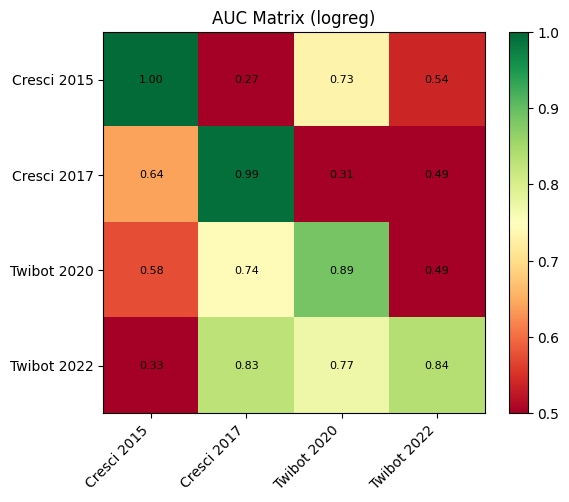

  saved figure: report/figures/04_viz__model__auc_matrix_ridge.png


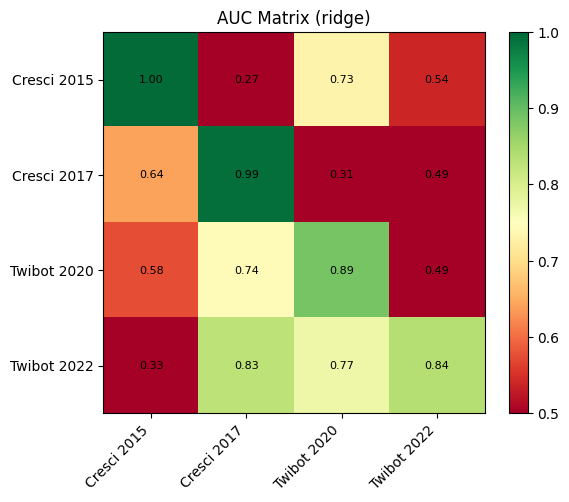

  saved figure: report/figures/04_viz__model__auc_matrix_lasso.png


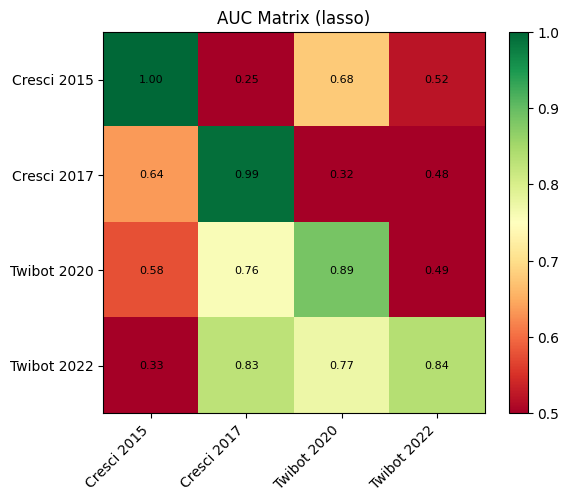

  saved figure: report/figures/04_viz__model__auc_matrix_rf.png


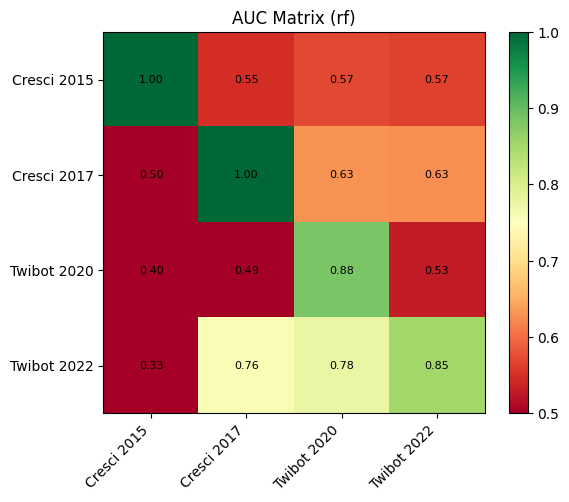

  saved figure: report/figures/04_viz__model__auc_matrix_xgb.png


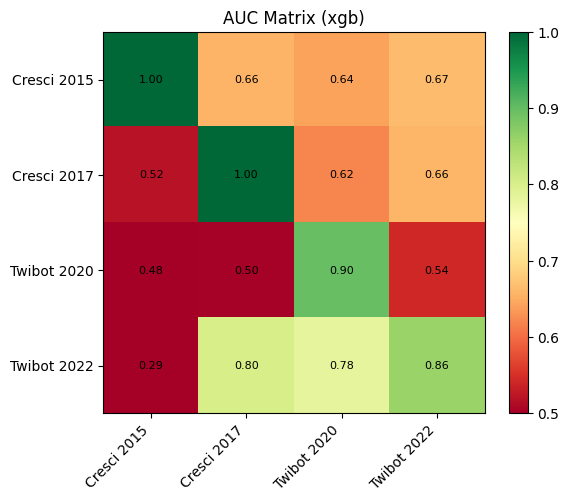

  saved figure: report/figures/04_viz__model__auc_matrix_svm.png


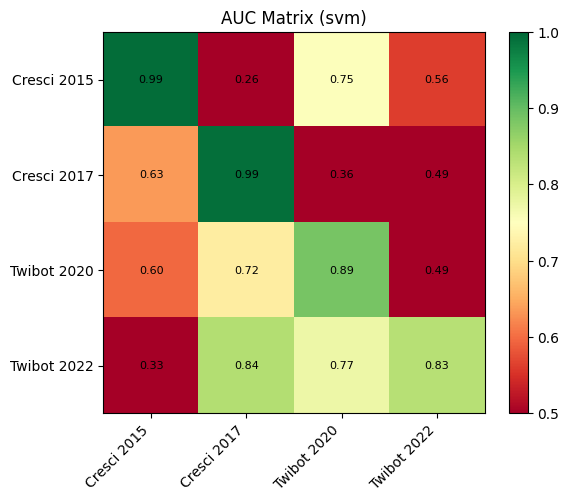

In [6]:
for model_type, df_auc in auc_matrices.items():
    fig = build_auc_heatmap(
        df_auc,
        title=f"AUC Matrix ({model_type})"
    )

    save_fig(f"04_viz__model__auc_matrix_{model_type}", fig)

### Bots-Over-Time Plots
Headline “bots over time” plots for every model. Each line corresponds to a training dataset, and the slope shows how performance degrades when applied to newer datasets. These plots directly support the central claim about bot evolution and model decay.

  saved figure: report/figures/04_viz__story__bots_over_time_logreg.png


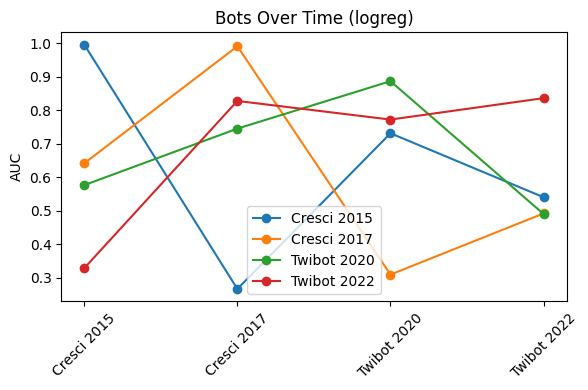

  saved figure: report/figures/04_viz__story__bots_over_time_ridge.png


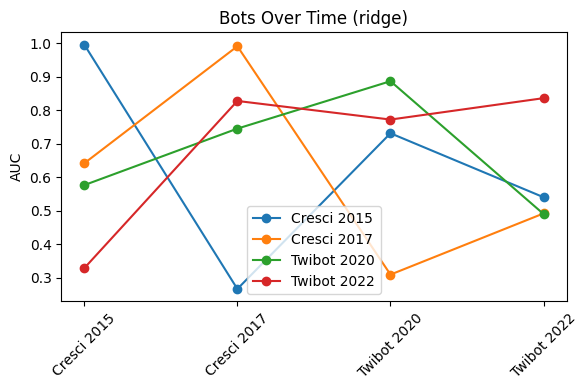

  saved figure: report/figures/04_viz__story__bots_over_time_lasso.png


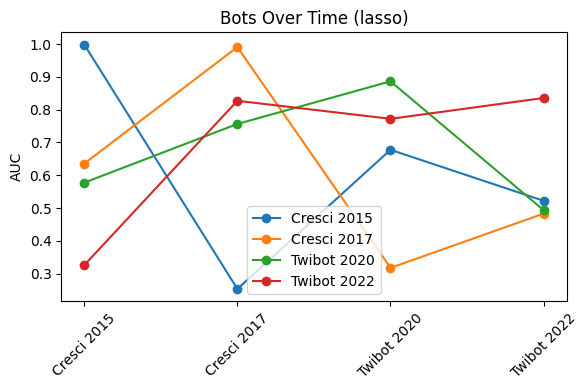

  saved figure: report/figures/04_viz__story__bots_over_time_rf.png


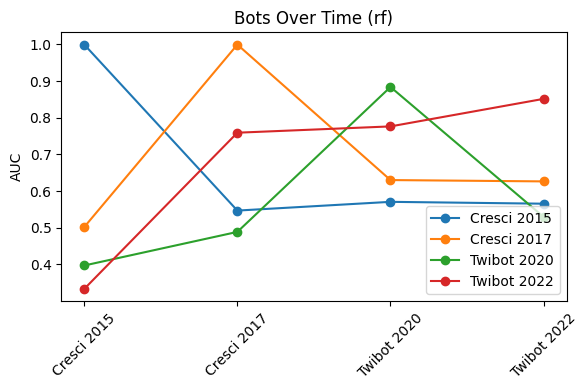

  saved figure: report/figures/04_viz__story__bots_over_time_xgb.png


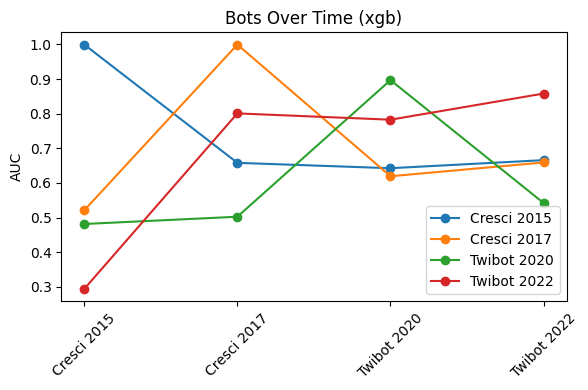

  saved figure: report/figures/04_viz__story__bots_over_time_svm.png


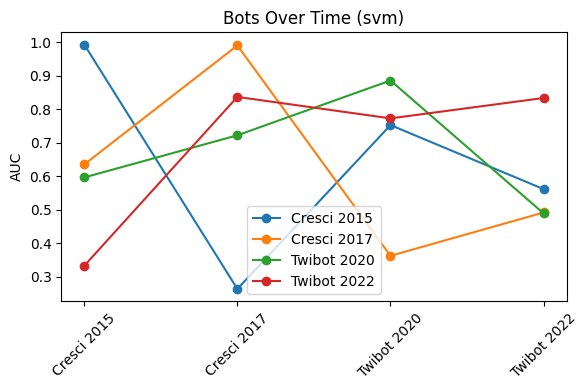

In [7]:
for model_type, df_auc in auc_matrices.items():
    fig = build_bots_over_time(
        df_auc,
        title=f"Bots Over Time ({model_type})"
    )

    save_fig(f"04_viz__story__bots_over_time_{model_type}", fig)

### Compute diagonal vs cross-era summary
Computes, for each training dataset, the difference between within-dataset performance (diagonal AUC) and average cross-era performance.

In [8]:
diag_cross_data = {}

for model_type in auc_matrices.keys():
    # We reconstruct results-like structure from matrices
    df_auc = auc_matrices[model_type]

    # Convert matrix → nested dict format expected by helper
    results_like = {
        tr: {
            te: {"auc": df_auc.loc[tr, te]}
            for te in DATASETS
        }
        for tr in DATASETS
    }

    diag_cross_data[model_type] = diagonal_vs_cross_auc(results_like, DATASETS)

print("Prepared diagonal vs cross-era summaries.")

Prepared diagonal vs cross-era summaries.


### Cross-era trends by training dataset
Mean cross-era AUC (averaged over all test datasets ≠ train) plotted per
training dataset, one line per model type. Drops as you move along the
x-axis show how much performance the model loses when applied to a dataset
other than the one it was trained on.


  saved figure: report/figures/04_viz__story__cross_era_trends_by_model.png


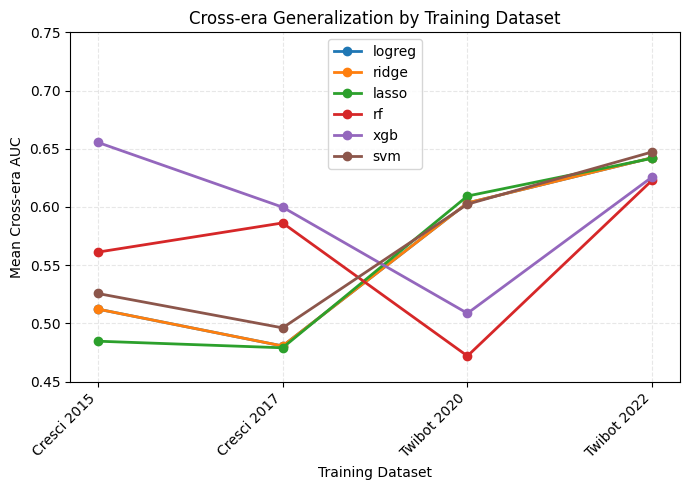

[PosixPath('/Users/ahteshamalvi/Files/CMSC/CMSC396H/Twibot_Detection_Research/report/figures/04_viz__story__cross_era_trends_by_model.png')]

In [9]:
fig, ax = plt.subplots(figsize=(7, 5))

# Ensure consistent dataset order
x_labels = [DATASET_LABELS[d] for d in DATASETS]
x_pos = np.arange(len(DATASETS))

for model_type, rows in diag_cross_data.items():
    # Keep order consistent with DATASETS
    rows_sorted = sorted(rows, key=lambda r: DATASETS.index(r["train_dataset"]))

    y = [r["mean_cross_auc"] for r in rows_sorted]

    ax.plot(
        x_pos,
        y,
        marker="o",
        label=model_type,
        linewidth=2
    )

# Axis formatting
ax.set_xticks(x_pos)
ax.set_xticklabels(x_labels, rotation=45, ha="right")

ax.set_ylabel("Mean Cross-era AUC")
ax.set_xlabel("Training Dataset")
ax.set_title("Cross-era Generalization by Training Dataset")

ax.set_ylim(0.45, 0.75)  # adjust if needed for your data
ax.grid(True, linestyle="--", alpha=0.3)

ax.legend()

save_fig("04_viz__story__cross_era_trends_by_model", fig)

### AUC degradation heatmaps

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_logreg.png


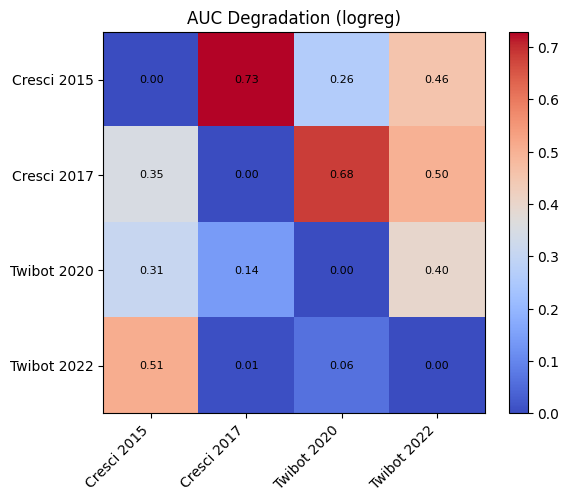

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_ridge.png


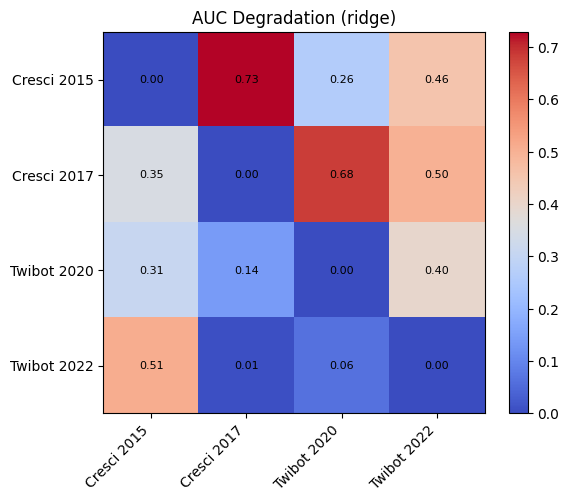

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_lasso.png


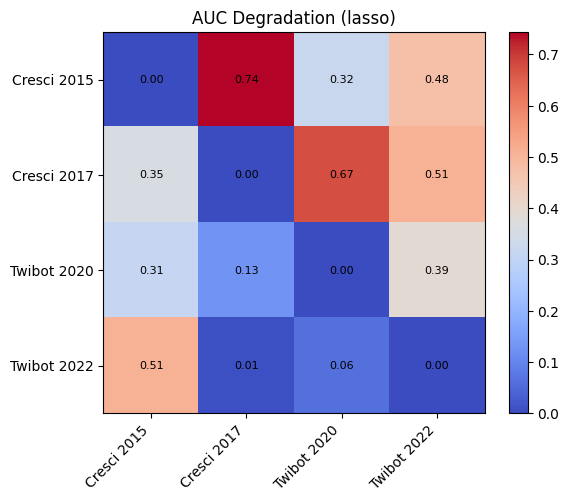

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_rf.png


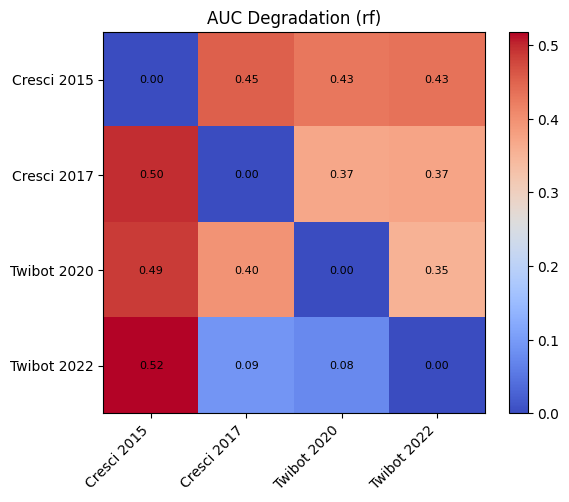

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_xgb.png


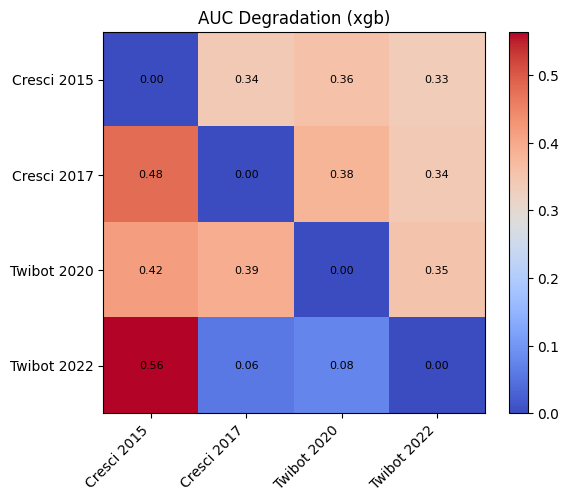

  saved figure: report/figures/04_viz__story__auc_degradation_heatmap_svm.png


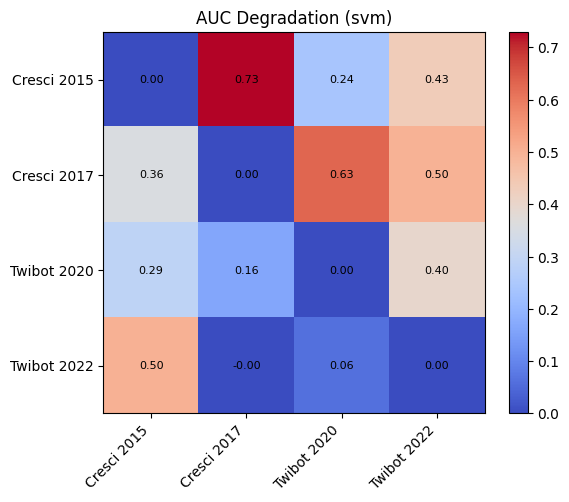

In [10]:
for model_type in auc_matrices.keys():
    df_auc = auc_matrices[model_type]

    # Convert to results-like structure
    results_like = {
        tr: {
            te: {"auc": df_auc.loc[tr, te]}
            for te in DATASETS
        }
        for tr in DATASETS
    }

    df_deg = auc_degradation_matrix(results_like, DATASETS)

    fig, _ = plot_heatmap(
        df_deg.values,
        x_labels=[DATASET_LABELS[d] for d in DATASETS],
        y_labels=[DATASET_LABELS[d] for d in DATASETS],
        title=f"AUC Degradation ({model_type})",
        cmap="coolwarm",
        vmin=0,
    )

    save_fig(f"04_viz__story__auc_degradation_heatmap_{model_type}", fig)

### AUC comparison across models
Heatmap compares all model types across every train–test pair. Each row is a dataset pair and each column is a model.

  saved figure: report/figures/04_viz__compare__auc_by_model_and_pair.png


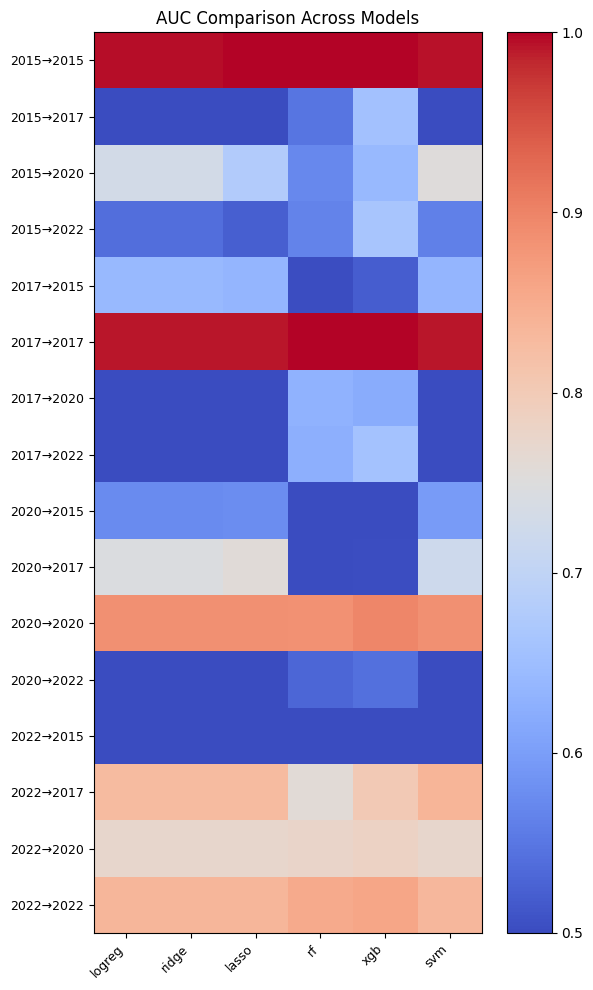

In [11]:
# ============================================================
# D1 — AUC comparison heatmap (cleaned)
# ============================================================

rows = []
index = []

for train_ds in DATASETS:
    for test_ds in DATASETS:
        pair_name = f"{train_ds.split('_')[-1]}→{test_ds.split('_')[-1]}"
        index.append(pair_name)

        row = {}
        for model_type, df_auc in auc_matrices.items():
            row[model_type] = df_auc.loc[train_ds, test_ds]

        rows.append(row)

df_compare = pd.DataFrame(rows, index=index)
    
# --- Plot ---
fig, ax = plt.subplots(figsize=(6, 10))  # tall + narrow

im = ax.imshow(df_compare.values, cmap="coolwarm", vmin=0.5, vmax=1.0, aspect="auto")

ax.set_xticks(np.arange(len(df_compare.columns)))
ax.set_yticks(np.arange(len(df_compare.index)))

ax.set_xticklabels(df_compare.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticklabels(df_compare.index, fontsize=9)

ax.set_title("AUC Comparison Across Models")

fig.colorbar(im, ax=ax)

save_fig("04_viz__compare__auc_by_model_and_pair", fig)

# Save data
df_compare.to_csv(
    PROJECT_ROOT / "report/figures/04_viz__compare__auc_by_model_and_pair.csv"
)

### Best model per pair
Identifies the best-performing model for each train–test pair.

  saved figure: report/figures/04_viz__compare__best_model_per_pair.png


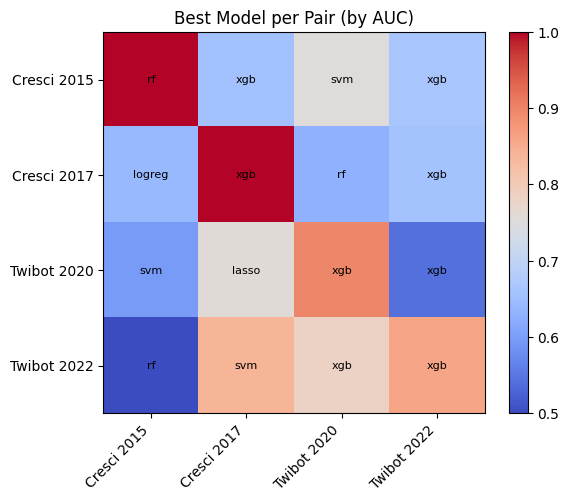

[PosixPath('/Users/ahteshamalvi/Files/CMSC/CMSC396H/Twibot_Detection_Research/report/figures/04_viz__compare__best_model_per_pair.png')]

In [12]:
best_model_matrix = []
best_labels = []

for train_ds in DATASETS:
    row_vals = []
    row_labels = []

    for test_ds in DATASETS:
        scores = {
            model_type: auc_matrices[model_type].loc[train_ds, test_ds]
            for model_type in auc_matrices.keys()
        }

        best_model = max(scores, key=scores.get)
        best_score = scores[best_model]

        row_vals.append(best_score)
        row_labels.append(best_model)

    best_model_matrix.append(row_vals)
    best_labels.append(row_labels)

best_model_matrix = np.array(best_model_matrix)

fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(best_model_matrix, cmap="coolwarm", vmin=0.5, vmax=1.0)

ax.set_xticks(np.arange(len(DATASETS)))
ax.set_yticks(np.arange(len(DATASETS)))
ax.set_xticklabels([DATASET_LABELS[d] for d in DATASETS], rotation=45, ha="right")
ax.set_yticklabels([DATASET_LABELS[d] for d in DATASETS])

# Annotate with model names
for i in range(len(DATASETS)):
    for j in range(len(DATASETS)):
        ax.text(
            j, i,
            best_labels[i][j],
            ha="center", va="center",
            fontsize=8,
            color="black"
        )

ax.set_title("Best Model per Pair (by AUC)")

fig.colorbar(im, ax=ax)

save_fig("04_viz__compare__best_model_per_pair", fig)

### Mean cross-era AUC by model
Computes the average cross-era AUC for each model type (excluding diagonal pairs). It identifies which model generalizes best across time.

  saved figure: report/figures/04_viz__compare__mean_auc_by_model.png


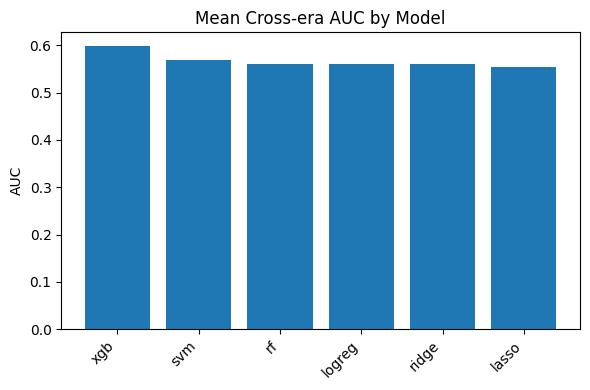

In [13]:
model_scores = {}

for model_type in auc_matrices.keys():
    df_auc = auc_matrices[model_type]

    results_like = {
        tr: {
            te: {"auc": df_auc.loc[tr, te]}
            for te in DATASETS
        }
        for tr in DATASETS
    }

    score = mean_cross_era_auc(results_like, DATASETS)
    model_scores[model_type] = score

# Convert to sorted series
s_scores = pd.Series(model_scores).sort_values(ascending=False)

fig, _ = plot_bar(
    values=s_scores.values,
    labels=s_scores.index,
    title="Mean Cross-era AUC by Model",
    ylabel="AUC",
)

save_fig("04_viz__compare__mean_auc_by_model", fig)

# Save underlying data
s_scores.to_csv(PROJECT_ROOT / "report/figures/04_viz__compare__mean_auc_by_model.csv")

### Feature availability heatmap
Visualizes which features are available (or missing) across datasets. Differences in feature availability explain why certain cross-era pairs perform worse—models cannot rely on signals that do not exist in the target dataset.

  saved figure: report/figures/04_viz__dataset__feature_availability.png


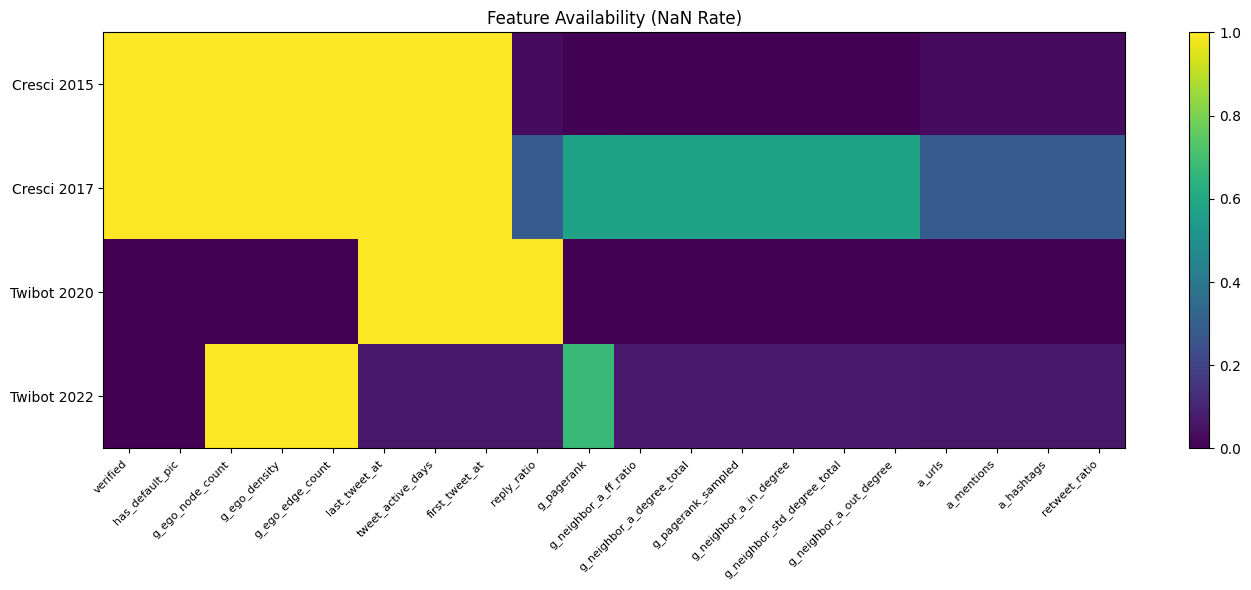

In [14]:
# Compute NaN rate per feature per dataset
feature_availability = []

for ds in DATASETS:
    sub = df_all[df_all["dataset"] == ds]
    nan_rate = sub.isna().mean()
    feature_availability.append(nan_rate)

df_availability = pd.DataFrame(feature_availability, index=DATASETS)

# --- Select most informative features (reduce clutter) ---
variability = df_availability.std(axis=0)

top_features = (
    variability
    .sort_values(ascending=False)
    .head(20)   # ↓ reduced from 40 → 20
    .index
)

df_plot = df_availability[top_features]

# --- Optional: shorten feature names slightly ---
def shorten_feature(name):
    return name.replace("graph_", "g_").replace("avg_", "a_")

short_cols = [shorten_feature(c) for c in df_plot.columns]

# --- Plot (manual, NOT plot_heatmap to control layout) ---
fig, ax = plt.subplots(figsize=(14, 6))  # ↑ wider + taller

im = ax.imshow(df_plot.values, cmap="viridis", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(np.arange(len(short_cols)))
ax.set_yticks(np.arange(len(df_plot.index)))

ax.set_xticklabels(short_cols, rotation=45, ha="right", fontsize=8)
ax.set_yticklabels([DATASET_LABELS[d] for d in df_plot.index], fontsize=10)

ax.set_title("Feature Availability (NaN Rate)")

fig.colorbar(im, ax=ax)

save_fig("04_viz__dataset__feature_availability", fig)

# Save underlying data
df_plot.to_csv(
    PROJECT_ROOT / "report/figures/04_viz__dataset__feature_availability.csv"
)

### Identify most degraded pairs
Identifies the cross-era pairs with the largest performance drops.

In [15]:
# Use one representative model (logreg is a good baseline)
df_auc = auc_matrices["logreg"]

results_like = {
    tr: {
        te: {"auc": df_auc.loc[tr, te]}
        for te in DATASETS
    }
    for tr in DATASETS
}

df_deg = auc_degradation_matrix(results_like, DATASETS)

# Flatten and sort
pairs = []
for tr in DATASETS:
    for te in DATASETS:
        if tr != te:
            pairs.append((tr, te, df_deg.loc[tr, te]))

# Sort by largest degradation
pairs_sorted = sorted(pairs, key=lambda x: x[2], reverse=True)

# Pick top 4 worst pairs
worst_pairs = pairs_sorted[:4]

print("Worst cross-era pairs:")
for p in worst_pairs:
    print(p)

Worst cross-era pairs:
('cresci_2015', 'cresci_2017', 0.7292092690800609)
('cresci_2017', 'twibot_2020', 0.6813172832604941)
('twibot_2022', 'cresci_2015', 0.5074178296001557)
('cresci_2017', 'twibot_2022', 0.4987880371158679)


### Feature importance plots
Visualizes feature importance for representative cases, including both within-dataset (diagonal) and the most degraded cross-era pairs. These plots reveal which signals models rely on and how those signals shift across time.


Processing model: logreg
  saved figure: report/figures/04_viz__features__importance_logreg__cresci_2015__on__cresci_2015.png


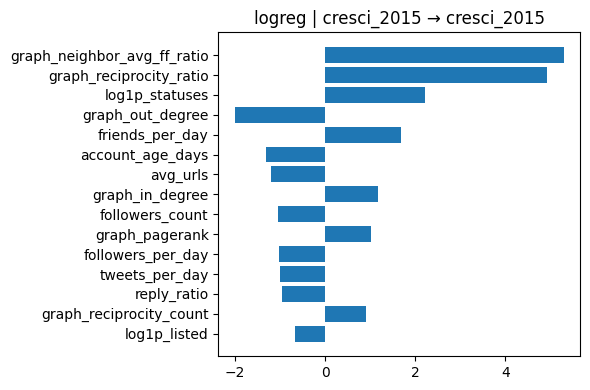

  saved figure: report/figures/04_viz__features__importance_logreg__cresci_2017__on__cresci_2017.png


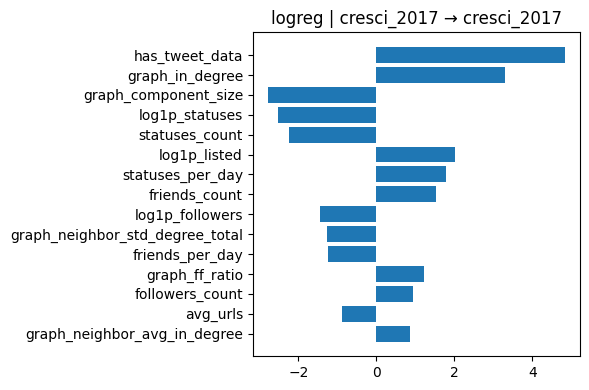

  saved figure: report/figures/04_viz__features__importance_logreg__twibot_2020__on__twibot_2020.png


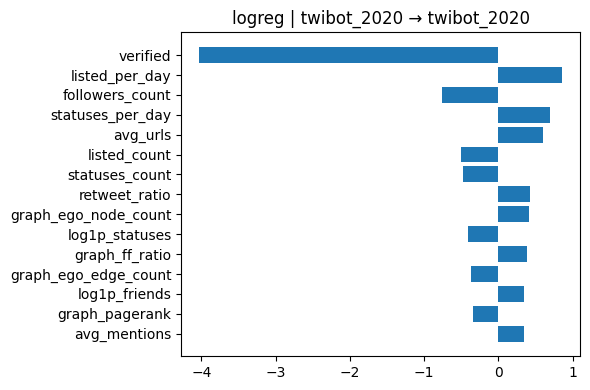

  saved figure: report/figures/04_viz__features__importance_logreg__twibot_2022__on__twibot_2022.png


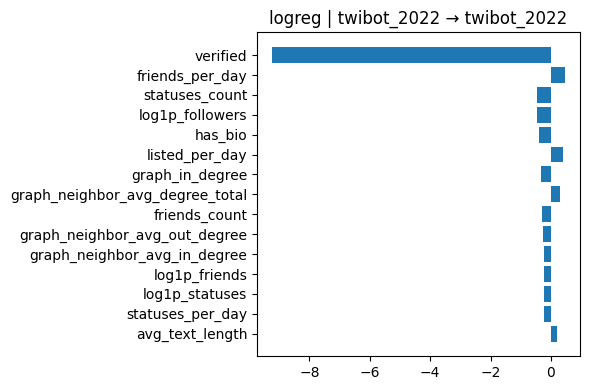

  saved figure: report/figures/04_viz__features__importance_logreg__cresci_2015__on__cresci_2017.png


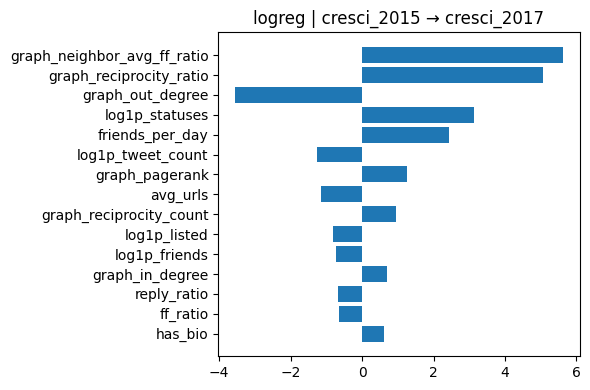

  saved figure: report/figures/04_viz__features__importance_logreg__cresci_2017__on__twibot_2020.png


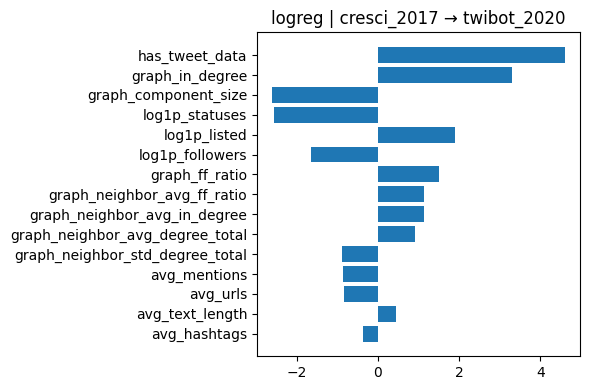

  saved figure: report/figures/04_viz__features__importance_logreg__twibot_2022__on__cresci_2015.png


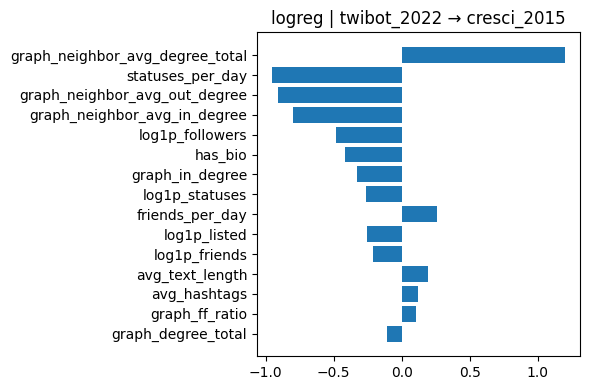

  saved figure: report/figures/04_viz__features__importance_logreg__cresci_2017__on__twibot_2022.png


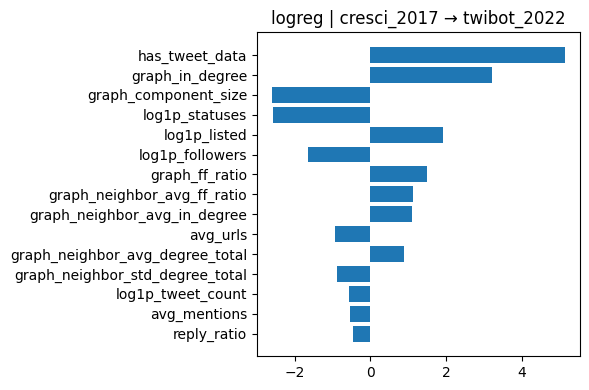


Processing model: ridge
  saved figure: report/figures/04_viz__features__importance_ridge__cresci_2015__on__cresci_2015.png


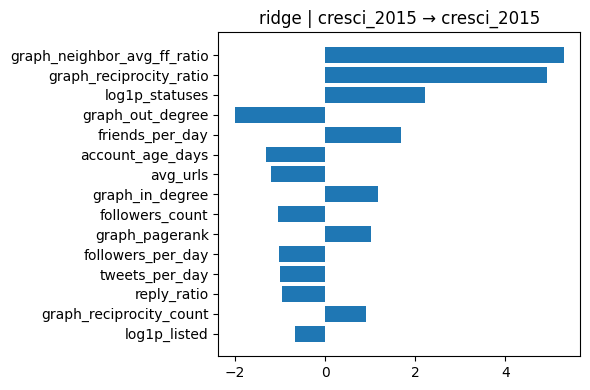

  saved figure: report/figures/04_viz__features__importance_ridge__cresci_2017__on__cresci_2017.png


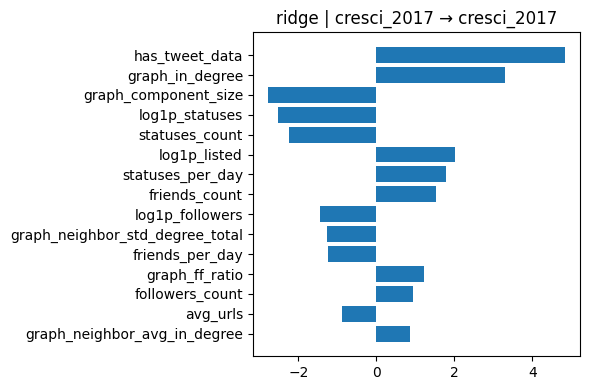

  saved figure: report/figures/04_viz__features__importance_ridge__twibot_2020__on__twibot_2020.png


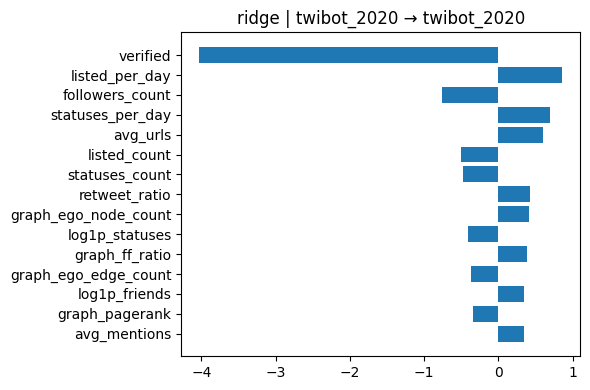

  saved figure: report/figures/04_viz__features__importance_ridge__twibot_2022__on__twibot_2022.png


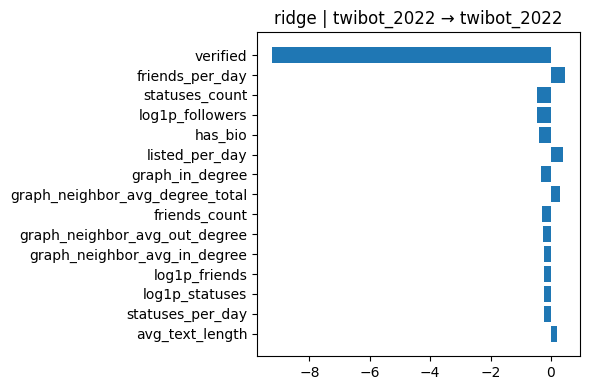

  saved figure: report/figures/04_viz__features__importance_ridge__cresci_2015__on__cresci_2017.png


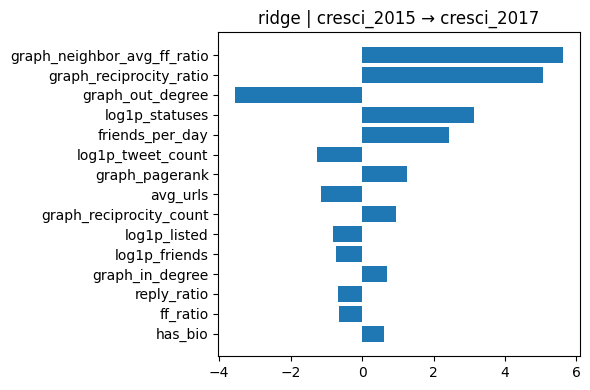

  saved figure: report/figures/04_viz__features__importance_ridge__cresci_2017__on__twibot_2020.png


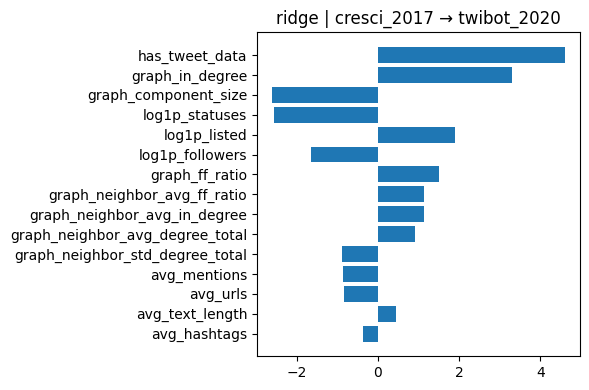

  saved figure: report/figures/04_viz__features__importance_ridge__twibot_2022__on__cresci_2015.png


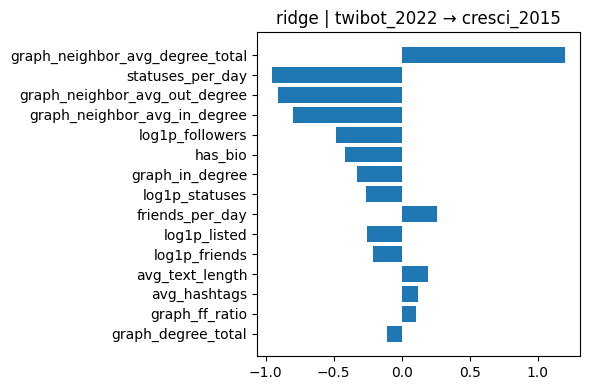

  saved figure: report/figures/04_viz__features__importance_ridge__cresci_2017__on__twibot_2022.png


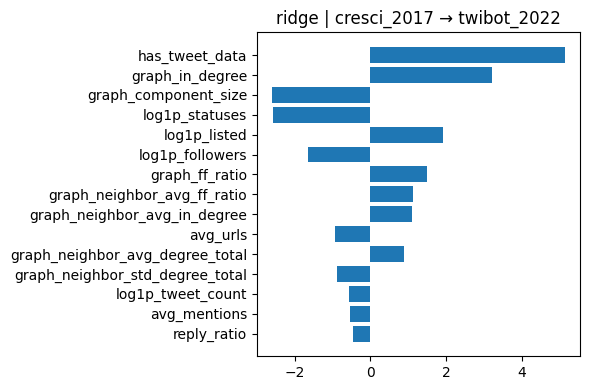


Processing model: lasso
  saved figure: report/figures/04_viz__features__importance_lasso__cresci_2015__on__cresci_2015.png


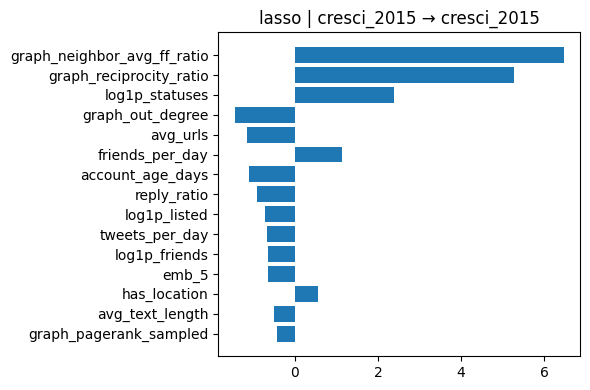

  saved figure: report/figures/04_viz__features__importance_lasso__cresci_2017__on__cresci_2017.png


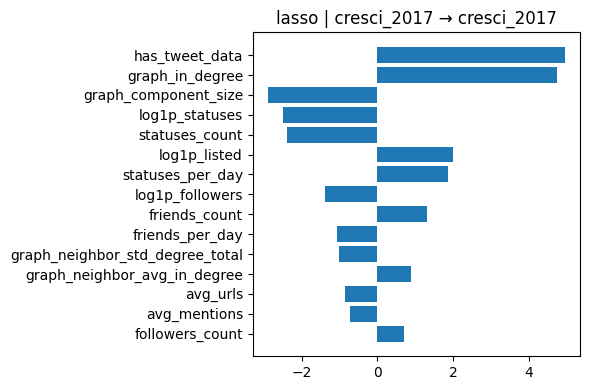

  saved figure: report/figures/04_viz__features__importance_lasso__twibot_2020__on__twibot_2020.png


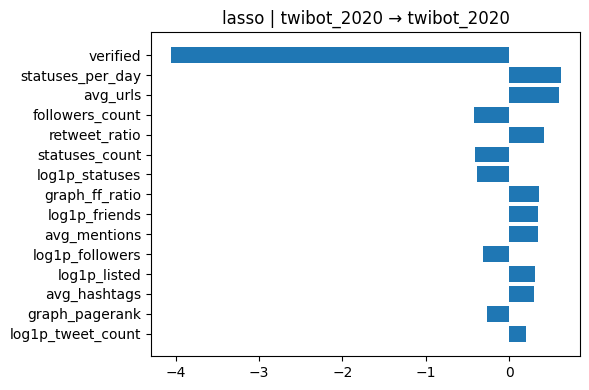

  saved figure: report/figures/04_viz__features__importance_lasso__twibot_2022__on__twibot_2022.png


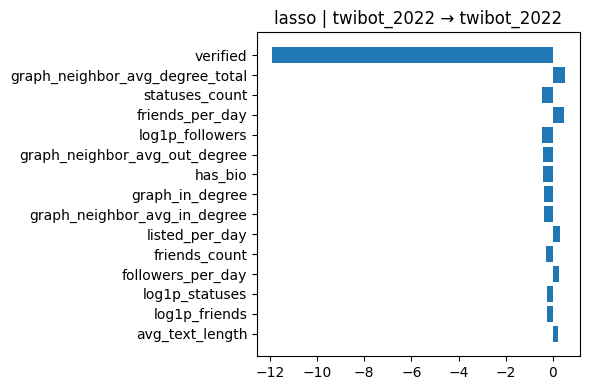

  saved figure: report/figures/04_viz__features__importance_lasso__cresci_2015__on__cresci_2017.png


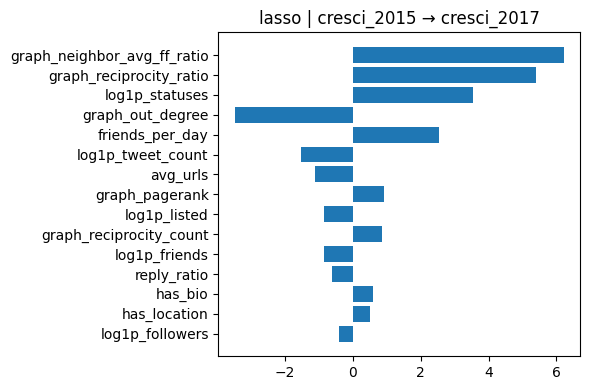

  saved figure: report/figures/04_viz__features__importance_lasso__cresci_2017__on__twibot_2020.png


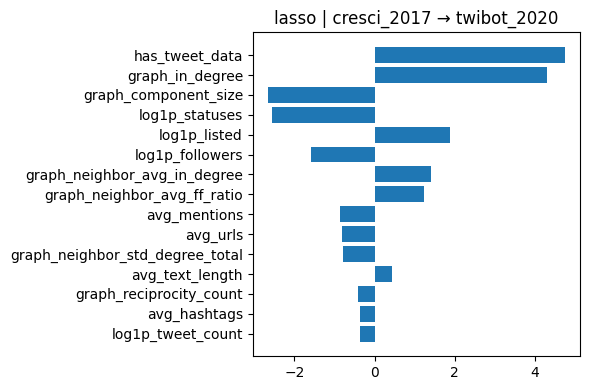

  saved figure: report/figures/04_viz__features__importance_lasso__twibot_2022__on__cresci_2015.png


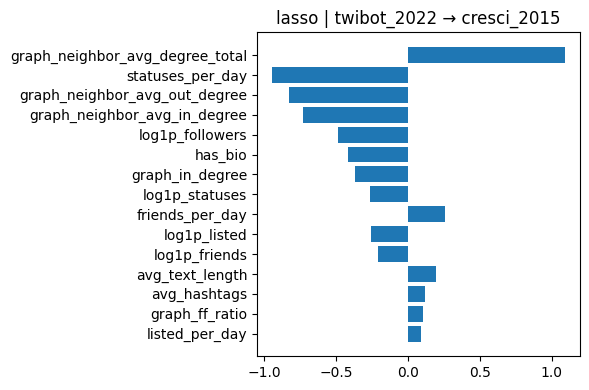

  saved figure: report/figures/04_viz__features__importance_lasso__cresci_2017__on__twibot_2022.png


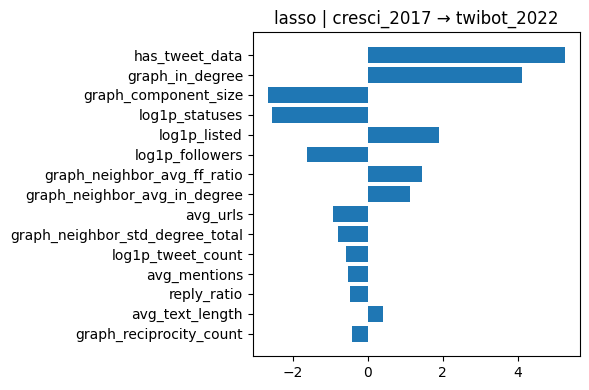


Processing model: rf
  saved figure: report/figures/04_viz__features__importance_rf__cresci_2015__on__cresci_2015.png


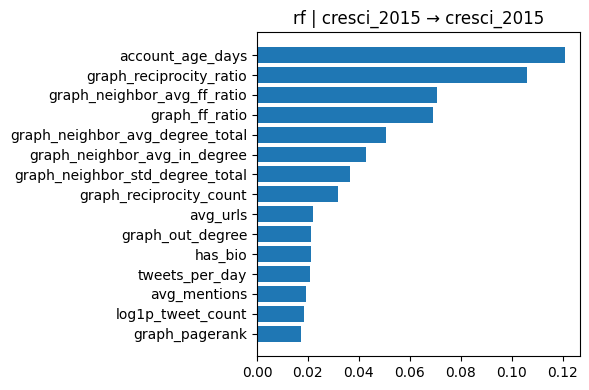

  saved figure: report/figures/04_viz__features__importance_rf__cresci_2017__on__cresci_2017.png


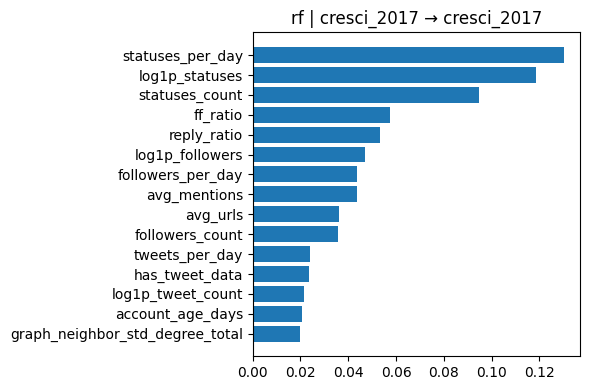

  saved figure: report/figures/04_viz__features__importance_rf__twibot_2020__on__twibot_2020.png


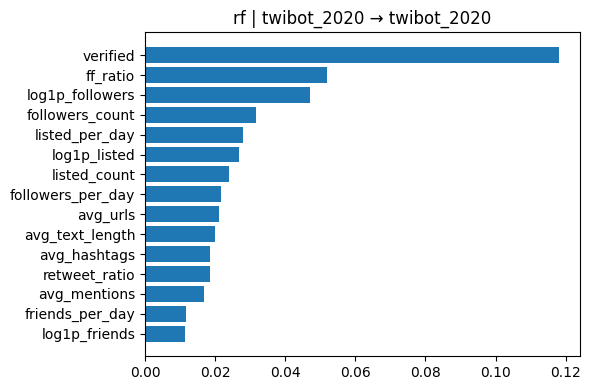

  saved figure: report/figures/04_viz__features__importance_rf__twibot_2022__on__twibot_2022.png


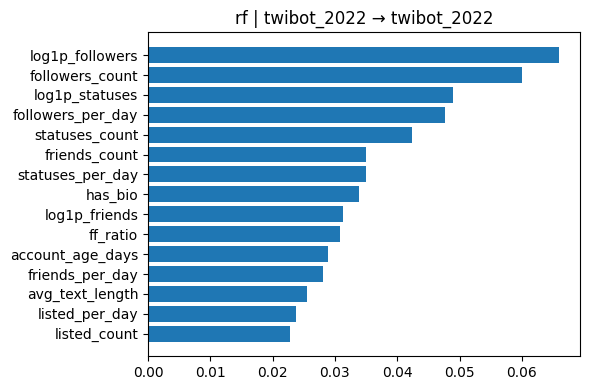

  saved figure: report/figures/04_viz__features__importance_rf__cresci_2015__on__cresci_2017.png


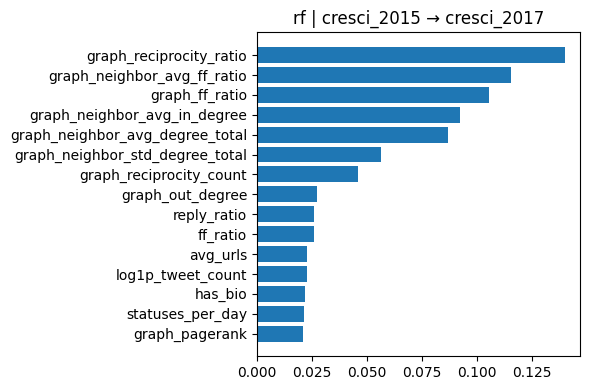

  saved figure: report/figures/04_viz__features__importance_rf__cresci_2017__on__twibot_2020.png


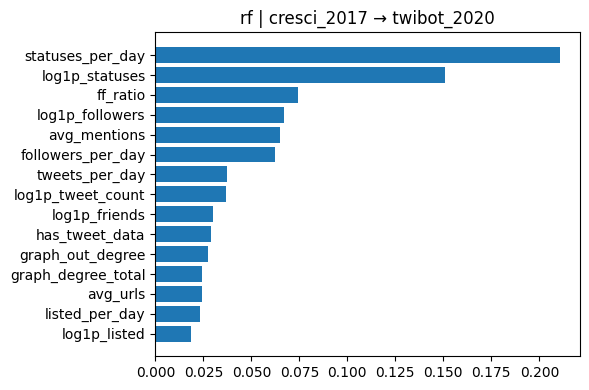

  saved figure: report/figures/04_viz__features__importance_rf__twibot_2022__on__cresci_2015.png


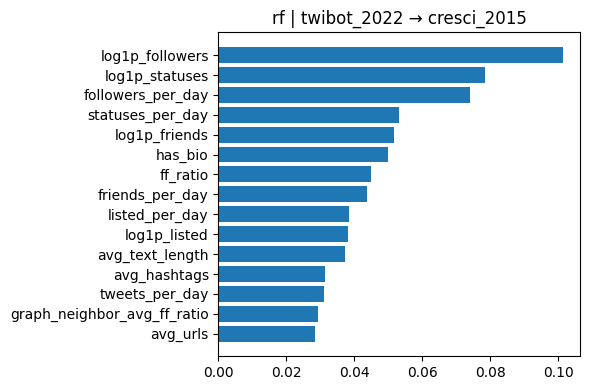

  saved figure: report/figures/04_viz__features__importance_rf__cresci_2017__on__twibot_2022.png


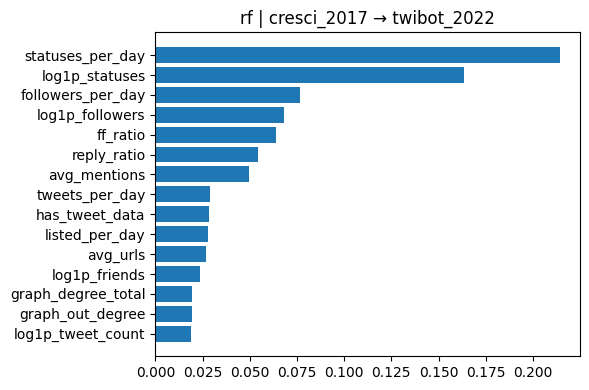


Processing model: xgb
  saved figure: report/figures/04_viz__features__importance_xgb__cresci_2015__on__cresci_2015.png


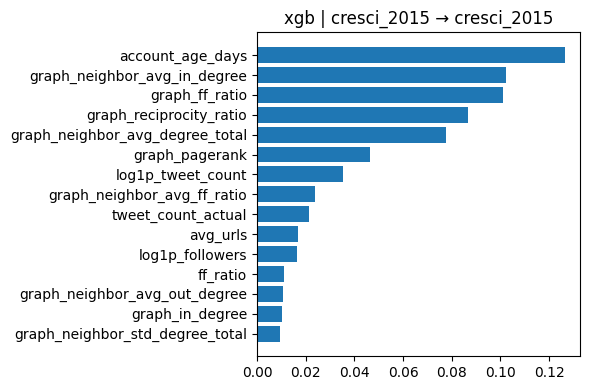

  saved figure: report/figures/04_viz__features__importance_xgb__cresci_2017__on__cresci_2017.png


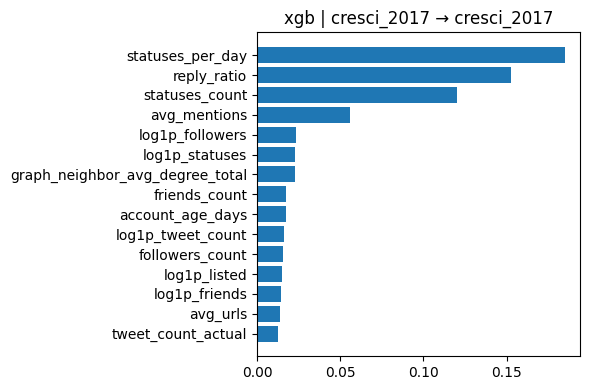

  saved figure: report/figures/04_viz__features__importance_xgb__twibot_2020__on__twibot_2020.png


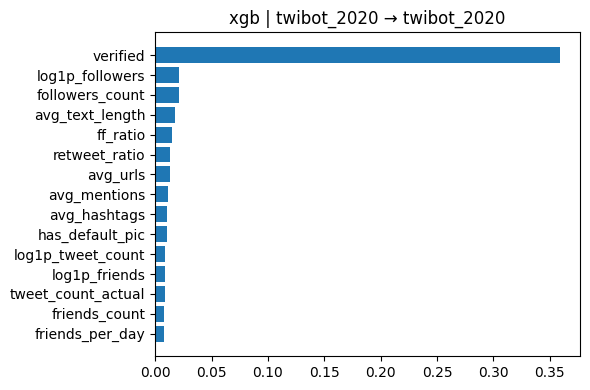

  saved figure: report/figures/04_viz__features__importance_xgb__twibot_2022__on__twibot_2022.png


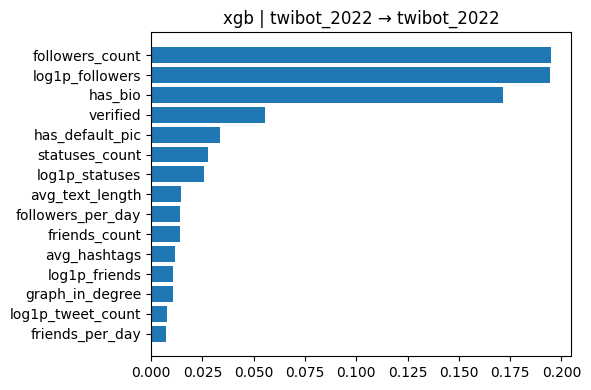

  saved figure: report/figures/04_viz__features__importance_xgb__cresci_2015__on__cresci_2017.png


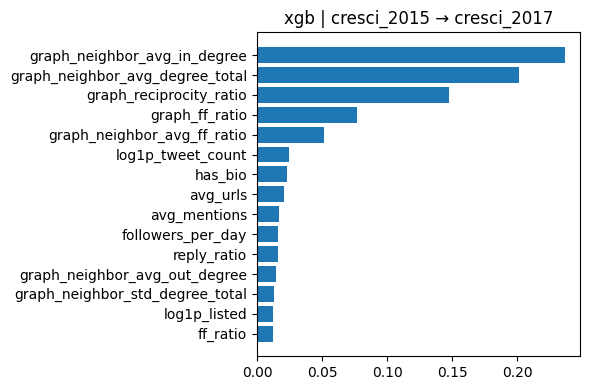

  saved figure: report/figures/04_viz__features__importance_xgb__cresci_2017__on__twibot_2020.png


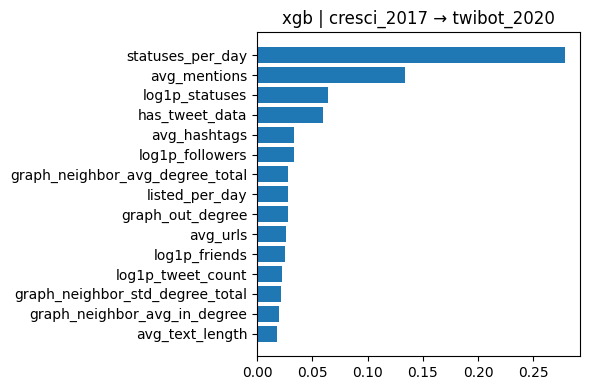

  saved figure: report/figures/04_viz__features__importance_xgb__twibot_2022__on__cresci_2015.png


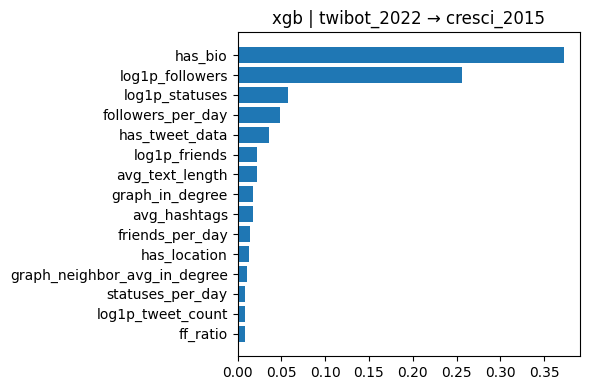

  saved figure: report/figures/04_viz__features__importance_xgb__cresci_2017__on__twibot_2022.png


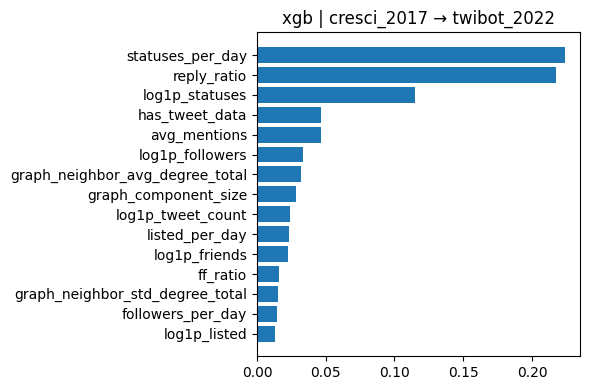


Processing model: svm
  saved figure: report/figures/04_viz__features__importance_svm__cresci_2015__on__cresci_2015.png


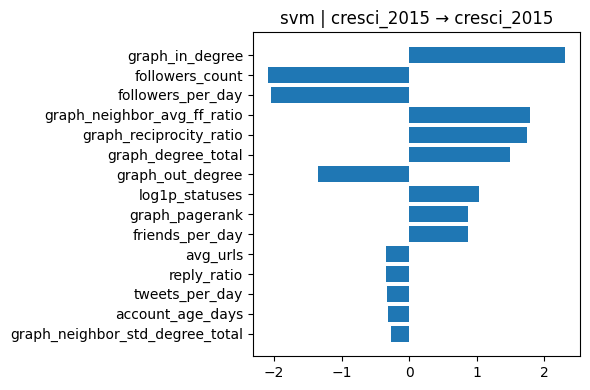

  saved figure: report/figures/04_viz__features__importance_svm__cresci_2017__on__cresci_2017.png


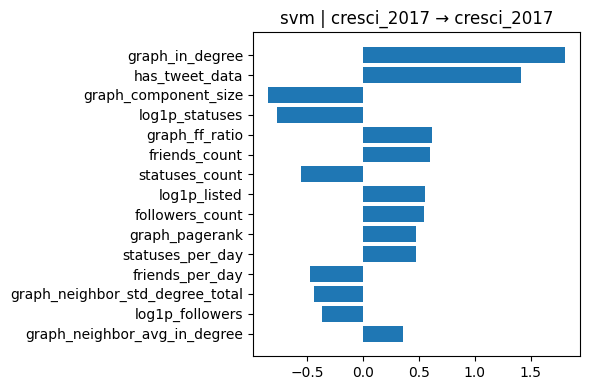

  saved figure: report/figures/04_viz__features__importance_svm__twibot_2020__on__twibot_2020.png


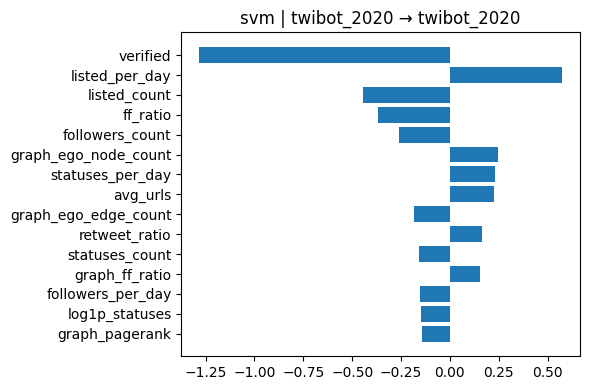

  saved figure: report/figures/04_viz__features__importance_svm__twibot_2022__on__twibot_2022.png


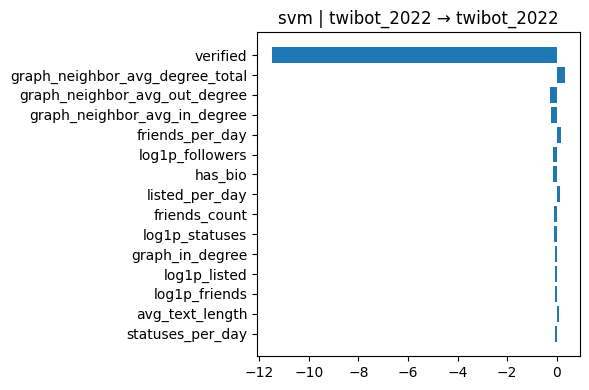

  saved figure: report/figures/04_viz__features__importance_svm__cresci_2015__on__cresci_2017.png


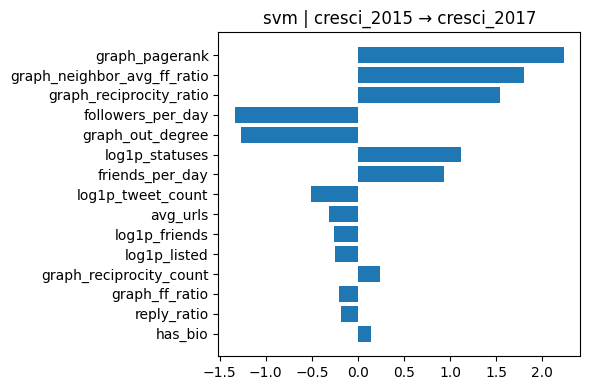

  saved figure: report/figures/04_viz__features__importance_svm__cresci_2017__on__twibot_2020.png


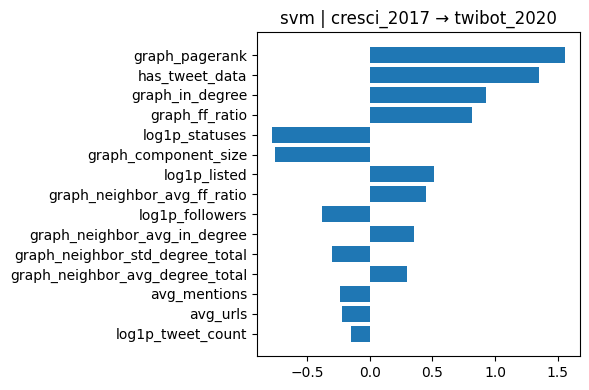

  saved figure: report/figures/04_viz__features__importance_svm__twibot_2022__on__cresci_2015.png


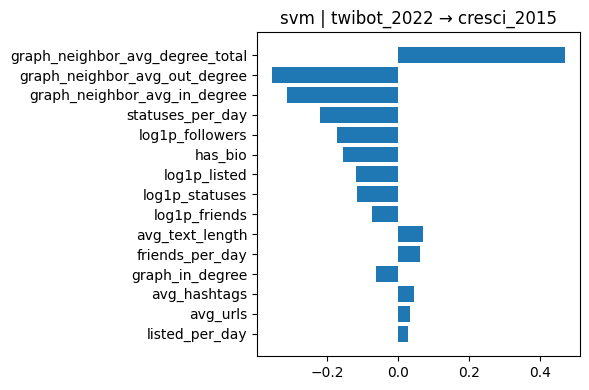

  saved figure: report/figures/04_viz__features__importance_svm__cresci_2017__on__twibot_2022.png


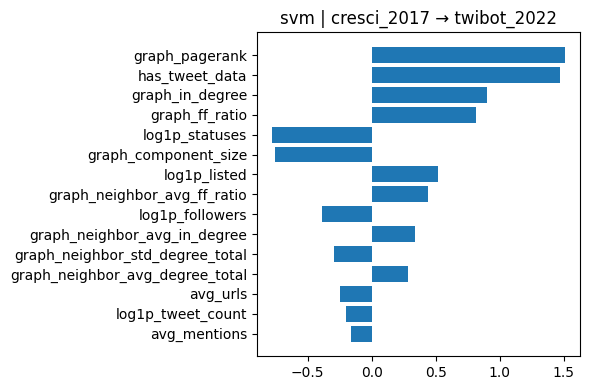


Total feature importance plots generated: 48


In [16]:
# Representative feature-importance plots only — one for each within-dataset
# diagonal plus the four most-degraded cross-era pairs from the previous cell.
# Generating all 96 (4×4×6) wastes disk and clutters report/figures/.
representative_pairs = (
    [(d, d) for d in DATASETS]
    + [(tr, te) for tr, te, _ in worst_pairs]
)

total_plots = 0

for model_type, models in models_by_type.items():
    print(f"\nProcessing model: {model_type}")

    for train_ds, test_ds in representative_pairs:
        if train_ds not in models or test_ds not in models[train_ds]:
            print(f"  skipping missing bundle: {train_ds} → {test_ds}")
            continue

        bundle = models[train_ds][test_ds]
        fig = build_feature_importance(bundle, top_k=15)

        save_fig(
            f"04_viz__features__importance_{model_type}__{train_ds}__on__{test_ds}",
            fig,
        )
        total_plots += 1

print(f"\nTotal feature importance plots generated: {total_plots}")


### Feature importance heatmap
Aggregates feature importance across all model–dataset pairs into a single heatmap.

Processing logreg...
  saved figure: report/figures/04_viz__features__importance_heatmap_logreg.png


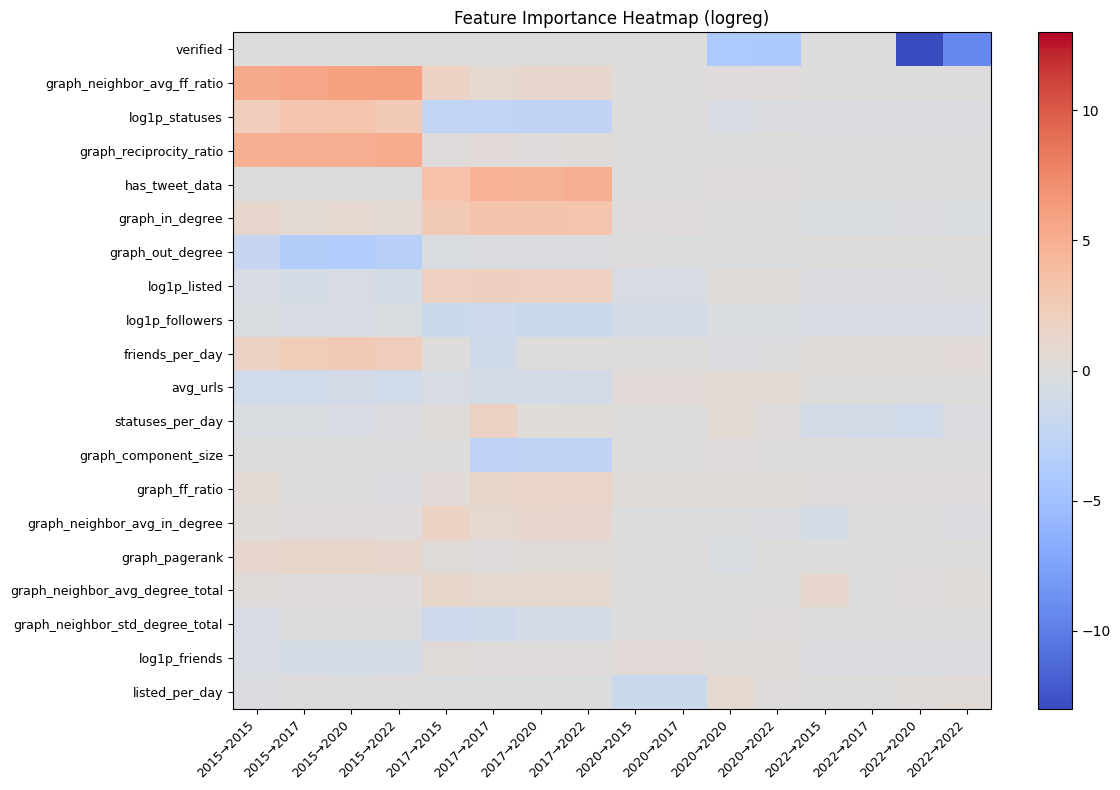

Processing ridge...
  saved figure: report/figures/04_viz__features__importance_heatmap_ridge.png


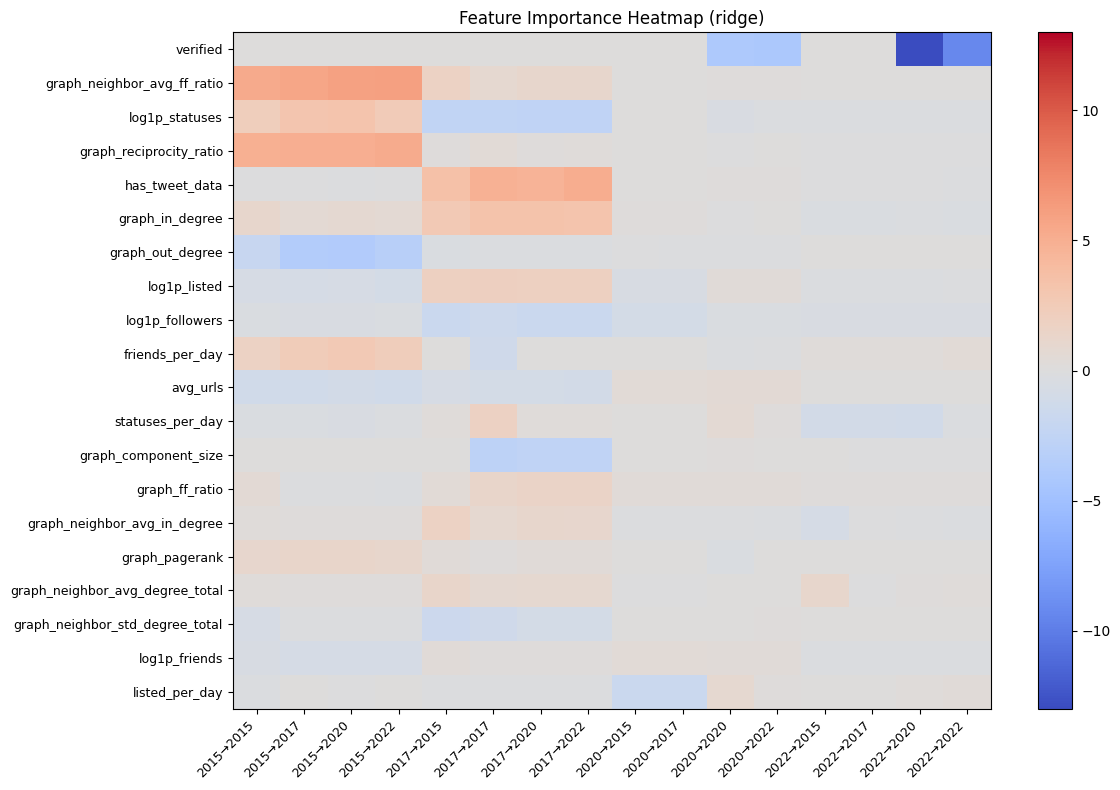

Processing lasso...
  saved figure: report/figures/04_viz__features__importance_heatmap_lasso.png


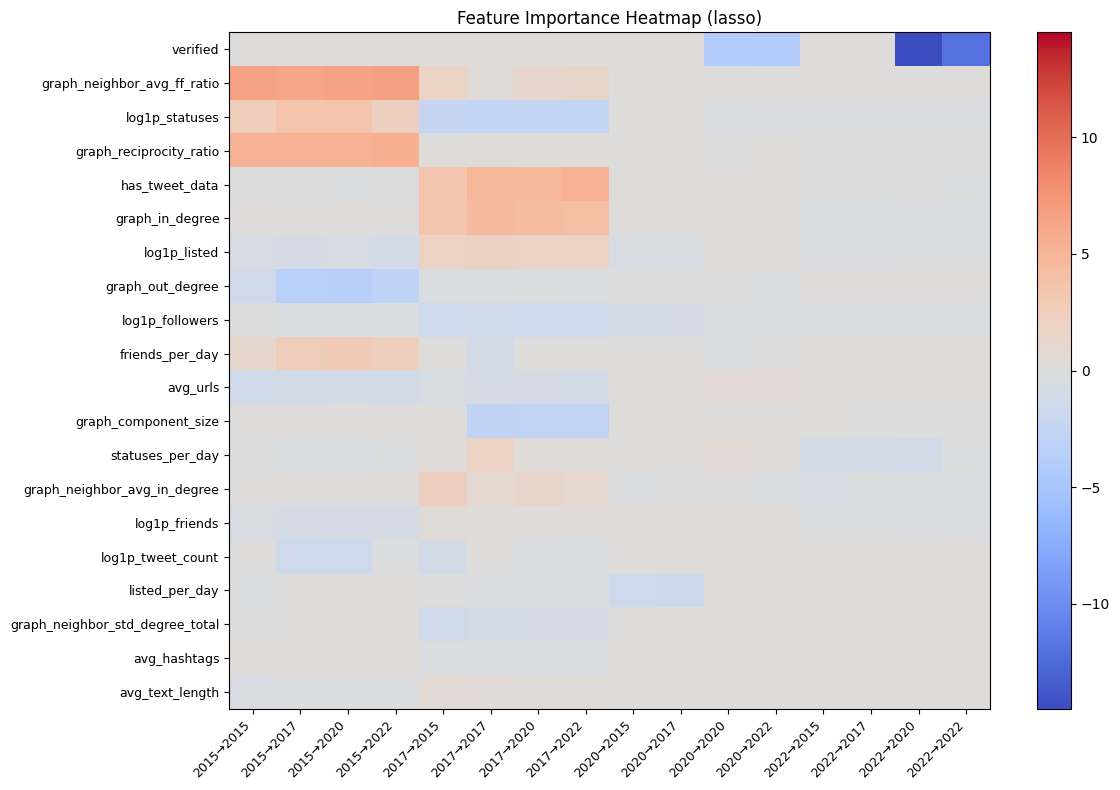

Processing rf...
  saved figure: report/figures/04_viz__features__importance_heatmap_rf.png


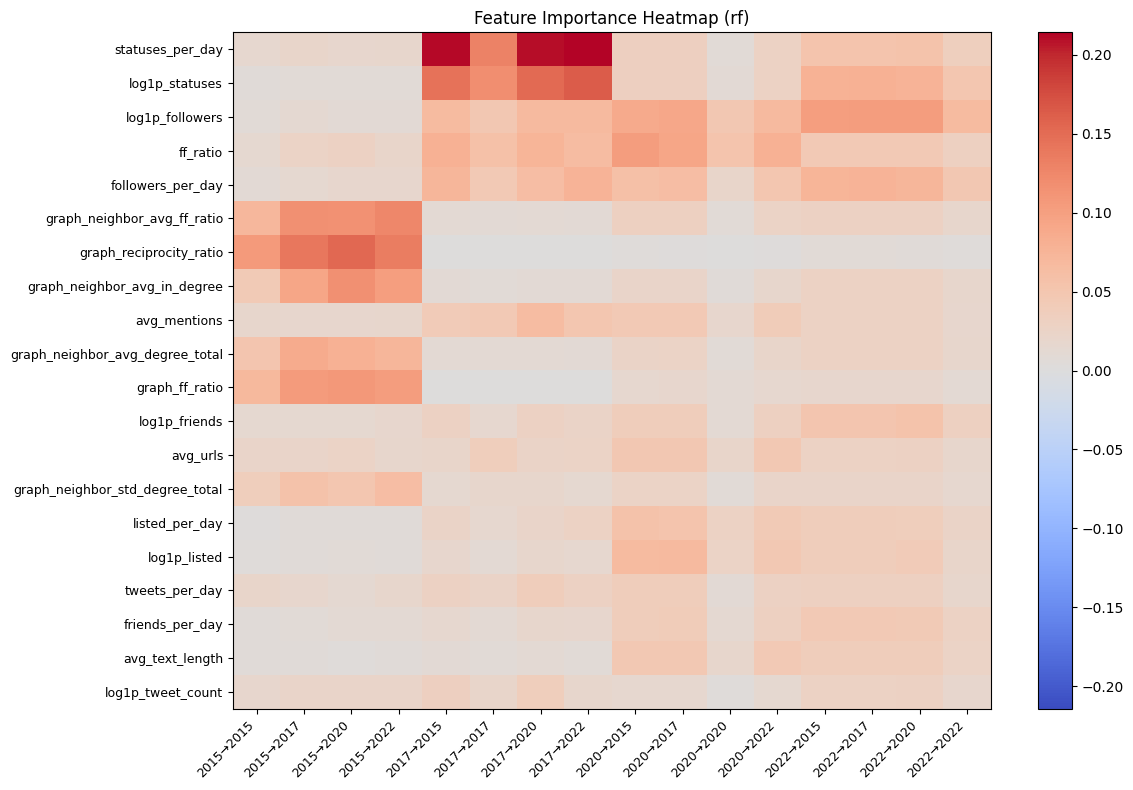

Processing xgb...
  saved figure: report/figures/04_viz__features__importance_heatmap_xgb.png


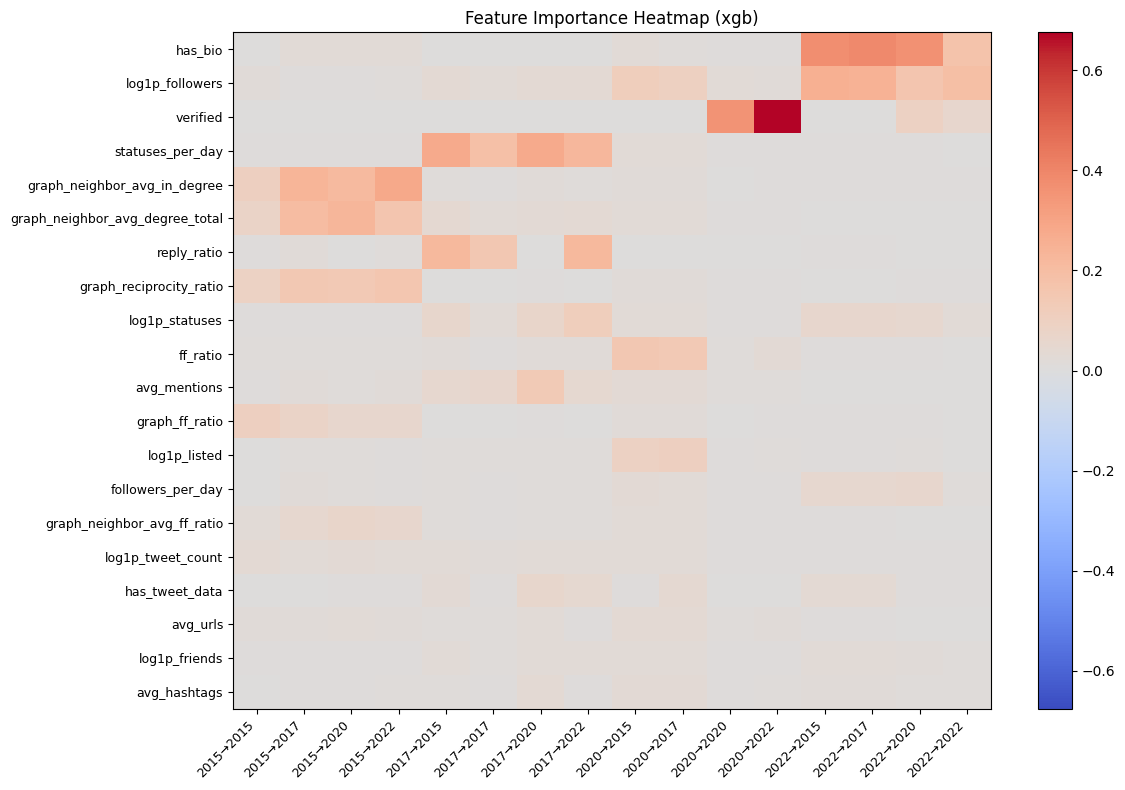

Processing svm...
  saved figure: report/figures/04_viz__features__importance_heatmap_svm.png


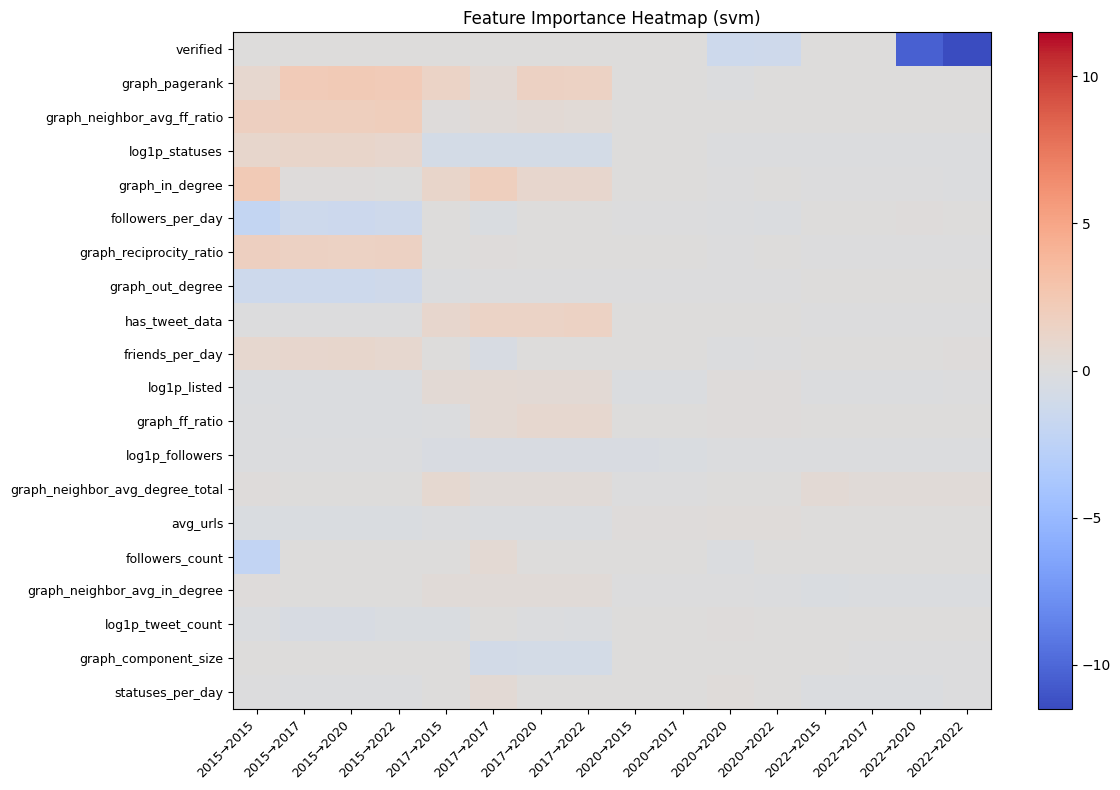

In [17]:
def shorten_pair_name(name):
    # cresci_2015__on__twibot_2022 → 2015→2022
    parts = name.split("__on__")
    return parts[0].split("_")[-1] + "→" + parts[1].split("_")[-1]


for model_type, models in models_by_type.items():
    print(f"Processing {model_type}...")

    df_imp = feature_importance_matrix(models)

    # Top-K features by mean |importance| across pairs.
    top_features = (
        df_imp.abs()
        .mean(axis=1)
        .sort_values(ascending=False)
        .head(20)
        .index
    )

    df_plot = df_imp.loc[top_features]

    short_cols = [shorten_pair_name(c) for c in df_plot.columns]

    # For linear models the coefficients are signed (positive = bot-leaning,
    # negative = human-leaning). A diverging colormap MUST be centered at 0,
    # otherwise the visual midpoint is the data midpoint and the sign cue is
    # misleading. We pin vmin/vmax to ±max(|values|).
    vmax = float(np.nanmax(np.abs(df_plot.values))) if df_plot.size else 1.0
    if vmax == 0:
        vmax = 1.0

    fig, ax = plt.subplots(figsize=(12, 8))
    im = ax.imshow(
        df_plot.values,
        cmap="coolwarm",
        aspect="auto",
        vmin=-vmax,
        vmax=vmax,
    )

    ax.set_xticks(np.arange(len(short_cols)))
    ax.set_yticks(np.arange(len(df_plot.index)))

    ax.set_xticklabels(short_cols, rotation=45, ha="right", fontsize=9)
    ax.set_yticklabels(df_plot.index, fontsize=9)

    ax.set_title(f"Feature Importance Heatmap ({model_type})")

    fig.colorbar(im, ax=ax)

    save_fig(f"04_viz__features__importance_heatmap_{model_type}", fig)

    df_plot.to_csv(
        PROJECT_ROOT / f"report/figures/04_viz__features__importance_heatmap_{model_type}.csv"
    )


## Graph Visualization

### Load graph features and edge lists
Loads precomputed graph features and edge lists for each dataset.

In [18]:
graph_features_by_ds = {}
edges_by_ds = {}

for ds in DATASETS:
    graph_path = PROCESSED_DIR / "round2_graph" / f"{ds}_graph_features.parquet"
    edges_path = PROCESSED_DIR / "edges" / f"{ds}_edges.parquet"

    if graph_path.exists():
        graph_features_by_ds[ds] = pd.read_parquet(graph_path)
        print(f"Loaded graph features: {ds}")

    if edges_path.exists():
        edges_by_ds[ds] = pd.read_parquet(edges_path)
        print(f"Loaded edges: {ds}")

Loaded graph features: cresci_2015
Loaded edges: cresci_2015
Loaded graph features: cresci_2017
Loaded edges: cresci_2017
Loaded graph features: twibot_2020
Loaded edges: twibot_2020
Loaded graph features: twibot_2022
Loaded edges: twibot_2022


### Degree distribution
Visualizes the degree distribution for each dataset, separated by bots and humans. Differences in degree patterns often reveal structural anomalies in bot behavior, such as inflated follower counts or abnormal connectivity.

  saved figure: report/figures/04_viz__graph__degree_distribution_cresci_2015.png


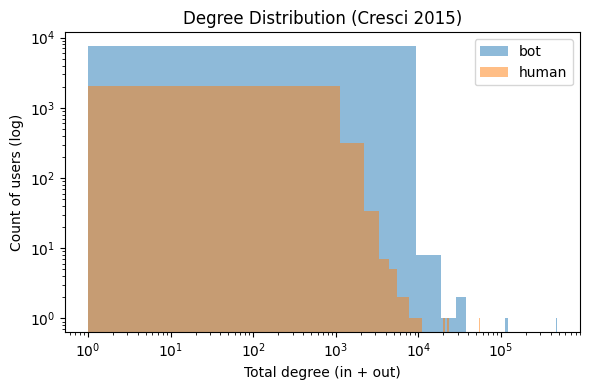

  saved figure: report/figures/04_viz__graph__degree_distribution_cresci_2017.png


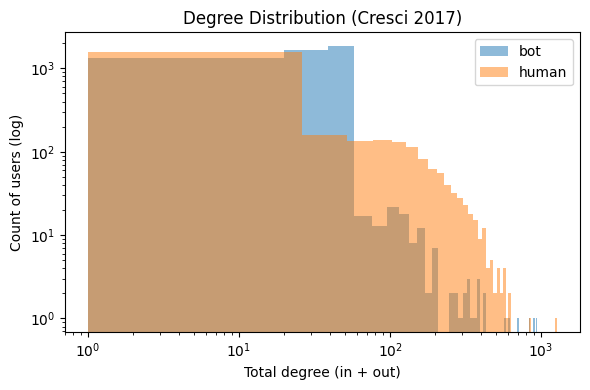

  saved figure: report/figures/04_viz__graph__degree_distribution_twibot_2020.png


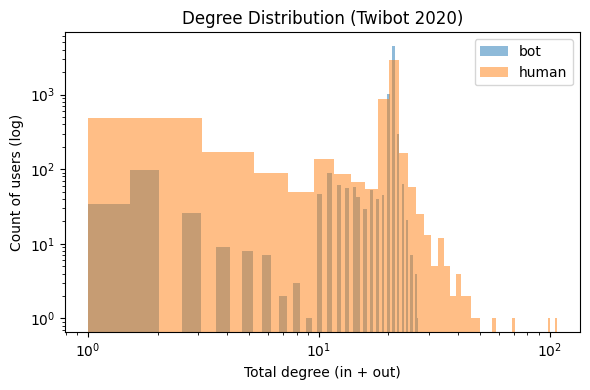

  saved figure: report/figures/04_viz__graph__degree_distribution_twibot_2022.png


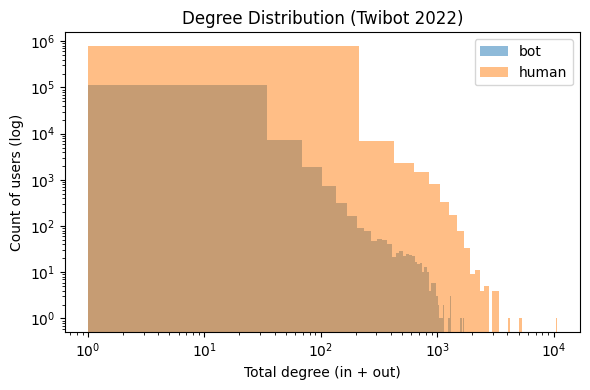

In [19]:
# Degree distribution per dataset, separated by label.
#
# `graph_features.py` emits `graph_in_degree`, `graph_out_degree`,
# `graph_degree_total` — there is no plain "degree" column, so the previous
# fallback `df.columns[1]` silently picked the dataset name string. We use
# `graph_degree_total` (sum of in + out) as the canonical "degree".
DEGREE_COL = "graph_degree_total"

for ds, df_graph in graph_features_by_ds.items():

    df = df_graph.merge(
        df_all[["user_id", "label"]],
        on="user_id",
        how="left",
    )

    if DEGREE_COL not in df.columns:
        print(f"  {ds}: {DEGREE_COL!r} missing, skipping")
        continue

    data = {
        "bot":   df.loc[df["label"] == "bot",   DEGREE_COL].dropna(),
        "human": df.loc[df["label"] == "human", DEGREE_COL].dropna(),
    }

    fig, ax = plot_histogram(
        data,
        bins=50,
        log=True,
        title=f"Degree Distribution ({DATASET_LABELS[ds]})",
    )
    # plot_histogram only sets xscale; degree distributions are heavy-tailed
    # in the count axis too, so log-log is much more readable.
    ax.set_yscale("log")
    ax.set_xlabel("Total degree (in + out)")
    ax.set_ylabel("Count of users (log)")

    save_fig(f"04_viz__graph__degree_distribution_{ds}", fig)


### Reciprocity by label
Compares reciprocity between bots and humans. Real users tend to have more mutual connections, while bots often exhibit asymmetric link patterns.

  saved figure: report/figures/04_viz__graph__reciprocity_by_label_cresci_2015.png


/var/folders/rs/fv7q9bln0tx2rdy0fhbblvsm0000gn/T/ipykernel_51850/780685208.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_vals, bot_vals], labels=["Human", "Bot"])


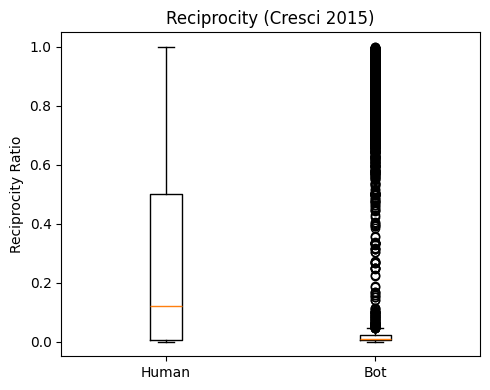

  saved figure: report/figures/04_viz__graph__reciprocity_by_label_cresci_2017.png


/var/folders/rs/fv7q9bln0tx2rdy0fhbblvsm0000gn/T/ipykernel_51850/780685208.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_vals, bot_vals], labels=["Human", "Bot"])


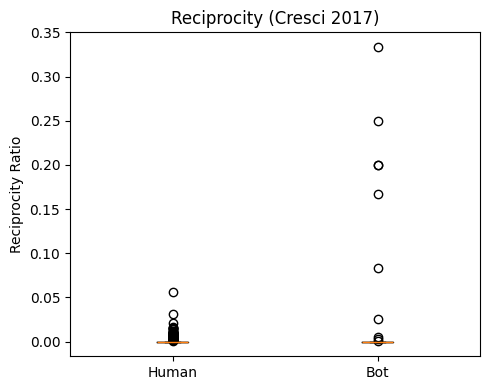

  saved figure: report/figures/04_viz__graph__reciprocity_by_label_twibot_2020.png


/var/folders/rs/fv7q9bln0tx2rdy0fhbblvsm0000gn/T/ipykernel_51850/780685208.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_vals, bot_vals], labels=["Human", "Bot"])


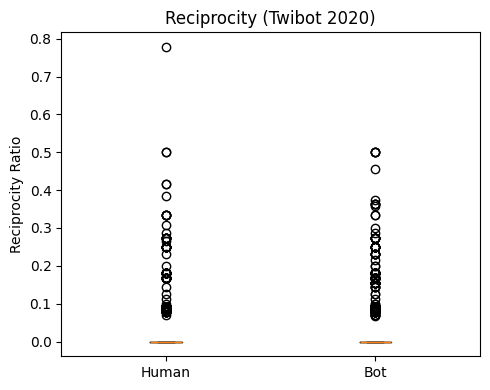

  saved figure: report/figures/04_viz__graph__reciprocity_by_label_twibot_2022.png


/var/folders/rs/fv7q9bln0tx2rdy0fhbblvsm0000gn/T/ipykernel_51850/780685208.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([human_vals, bot_vals], labels=["Human", "Bot"])


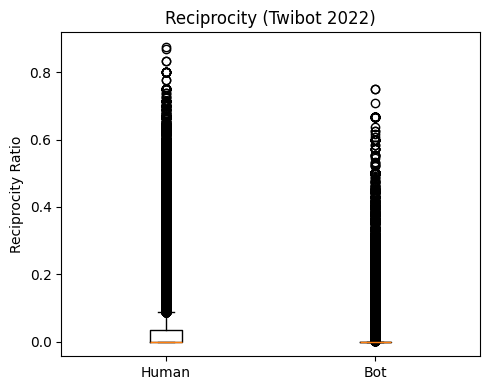

In [20]:
for ds, df_graph in graph_features_by_ds.items():

    df = df_graph.merge(
        df_all[["user_id", "label"]],
        on="user_id",
        how="left"
    )

    if "graph_reciprocity_ratio" not in df.columns:
        continue

    bot_vals = df[df["label"] == "bot"]["graph_reciprocity_ratio"].dropna()
    human_vals = df[df["label"] == "human"]["graph_reciprocity_ratio"].dropna()

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.boxplot([human_vals, bot_vals], labels=["Human", "Bot"])

    ax.set_title(f"Reciprocity ({DATASET_LABELS[ds]})")
    ax.set_ylabel("Reciprocity Ratio")

    save_fig(f"04_viz__graph__reciprocity_by_label_{ds}", fig)

### Graph visualization
Constructs a sampled subgraph and visualizes it using a force-directed layout. Nodes are colored by label, illustrating clustering patterns and connectivity differences between bots and humans. This is an illustrative figure intended to provide intuition, not quantitative analysis.


cresci_2015
  saved figure: report/figures/04_viz__graph__bot_ego_subgraph_cresci_2015.png


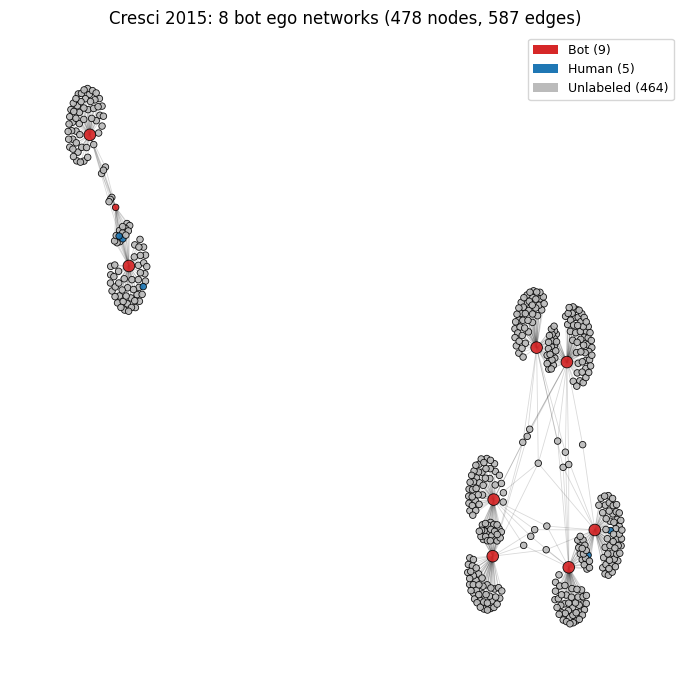


cresci_2017
  saved figure: report/figures/04_viz__graph__bot_ego_subgraph_cresci_2017.png


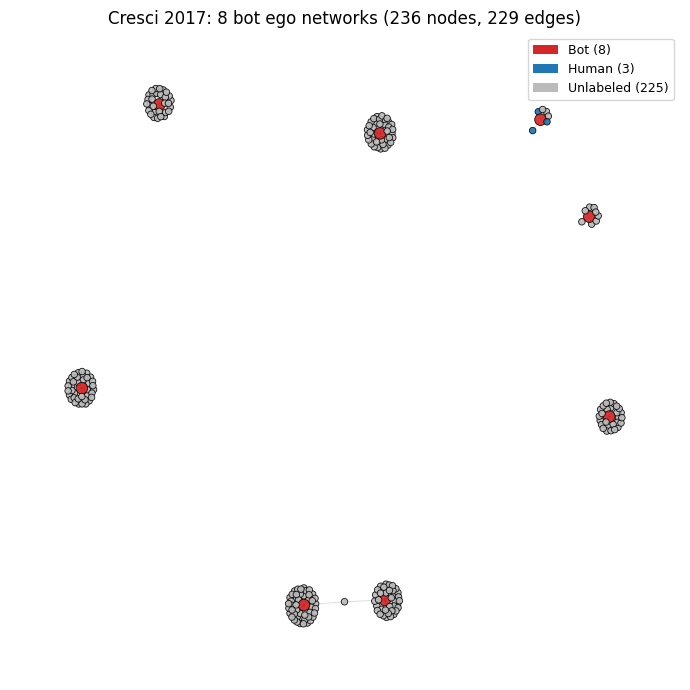


twibot_2020
  saved figure: report/figures/04_viz__graph__bot_ego_subgraph_twibot_2020.png


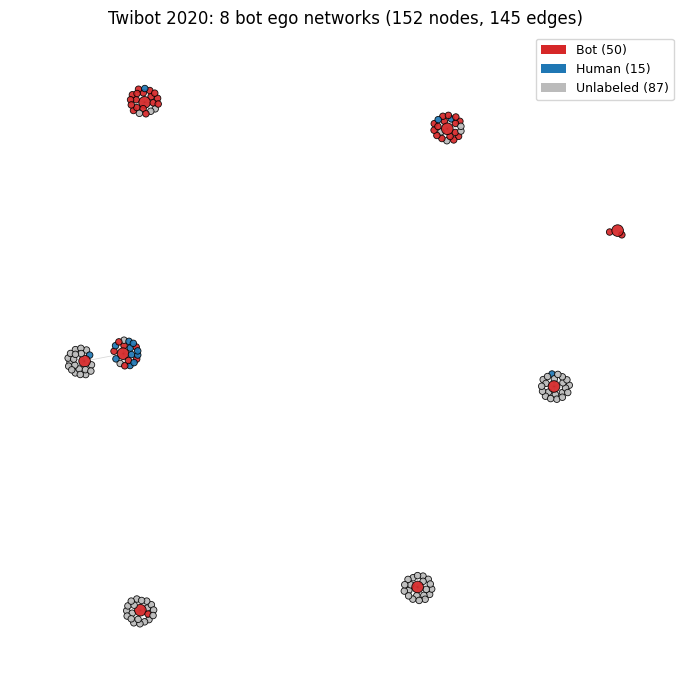


twibot_2022


In [ ]:
# ============================================================
# B4 — Bot-anchored ego networks
# ============================================================

import collections
import networkx as nx
import numpy as np
from matplotlib.patches import Patch

ANCHOR_BOTS          = 8       # number of bot ego centers
NEIGHBORS_PER_ANCHOR = 60      # cap per ego to avoid hub blowup
MAX_TOTAL_NODES      = 600     # final visualization cap
SEED                 = 42

UNLABELED_COLOR = "#bbbbbb"
COLOR_FOR = {
    "bot":       LABEL_COLORS["bot"],
    "human":     LABEL_COLORS["human"],
    "unlabeled": UNLABELED_COLOR,
}

# Build a single user_id → label lookup once. Anything not in this
# lookup is genuinely "unlabeled" (a neighbor that bled through from
# the edge data but isn't in the labeled user set).
label_map = (
    df_all.dropna(subset=["label"])
          .set_index("user_id")["label"]
          .to_dict()
)

def label_of(node):
    return label_map.get(node, "unlabeled") or "unlabeled"


for ds, edges_df in edges_by_ds.items():
    print(f"\n{ds}")

    G_full = nx.from_pandas_edgelist(
        edges_df, source="source_id", target="target_id"
    )
    if len(G_full) == 0:
        print("  empty graph; skipping")
        continue

    rng = np.random.default_rng(SEED)

    # Anchors: labeled bots that actually appear in this graph.
    bot_nodes_in_graph = [n for n in G_full.nodes() if label_of(n) == "bot"]
    if not bot_nodes_in_graph:
        print(f"  no labeled bots in graph; skipping")
        continue

    n_anchors = min(ANCHOR_BOTS, len(bot_nodes_in_graph))
    anchors = list(rng.choice(bot_nodes_in_graph, size=n_anchors, replace=False))

    # 1-hop ego with a per-anchor neighbor cap so a single hub doesn't
    # swallow the whole figure.
    sampled = set(anchors)
    for anchor in anchors:
        neighbors = list(G_full.neighbors(anchor))
        if len(neighbors) > NEIGHBORS_PER_ANCHOR:
            neighbors = list(
                rng.choice(neighbors, size=NEIGHBORS_PER_ANCHOR, replace=False)
            )
        sampled.update(neighbors)

    # Hard cap on total nodes (keeps anchors no matter what).
    if len(sampled) > MAX_TOTAL_NODES:
        non_anchors = list(sampled - set(anchors))
        keep = list(rng.choice(
            non_anchors,
            size=MAX_TOTAL_NODES - len(anchors),
            replace=False,
        ))
        sampled = set(anchors) | set(keep)

    G = G_full.subgraph(sampled).copy()

    # 3-way coloring + larger anchor markers so eye finds the centers.
    anchor_set = set(anchors)
    node_colors = [COLOR_FOR[label_of(n)] for n in G.nodes()]
    node_sizes  = [70 if n in anchor_set else 22 for n in G.nodes()]
    edgecolors  = ["black" if n in anchor_set else "none" for n in G.nodes()]

    pos = nx.spring_layout(
        G,
        seed=SEED,
        k=1.5 / np.sqrt(len(G)),
        iterations=150,
    )

    fig, ax = plt.subplots(figsize=(7, 7))
    nx.draw_networkx_edges(G, pos, alpha=0.15, width=0.6, ax=ax)
    nx.draw_networkx_nodes(
        G, pos,
        node_color=node_colors,
        node_size=node_sizes,
        edgecolors=edgecolors,
        linewidths=0.6,
        alpha=0.92,
        ax=ax,
    )

    # Legend with counts so the figure is self-describing.
    counts = collections.Counter(label_of(n) for n in G.nodes())
    legend_handles = [
        Patch(facecolor=COLOR_FOR["bot"],       label=f"Bot ({counts.get('bot', 0)})"),
        Patch(facecolor=COLOR_FOR["human"],     label=f"Human ({counts.get('human', 0)})"),
        Patch(facecolor=COLOR_FOR["unlabeled"], label=f"Unlabeled ({counts.get('unlabeled', 0)})"),
    ]
    ax.legend(handles=legend_handles, loc="upper right",
              frameon=True, fontsize=9)

    ax.set_title(
        f"{DATASET_LABELS[ds]}: {n_anchors} bot ego networks "
        f"({G.number_of_nodes()} nodes, {G.number_of_edges()} edges)"
    )
    ax.axis("off")

    save_fig(f"04_viz__graph__bot_ego_subgraph_{ds}", fig)